# Experiment 0: Benchmark against Standard SSM

Compares CTDS against a standard unconstrained linear dynamical system (SSM) on synthetic data. Evaluates log-likelihood, parameter recovery, and latent trajectory alignment.

**Requires:** `jax_enable_x64=True` (set in first code cell).

In [16]:
# Setup and Imports
import jax
jax.config.update("jax_enable_x64", True)

In [17]:

import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
#import seaborn as sns
from typing import Tuple, Optional
import time
#from functools import partial
import seaborn as sns
# Configure JAX for float64 precision
#print(f"NumPy version: {np.__version__}")
#print(f"Matplotlib version: {matplotlib.__version__}")
#print(f"JAX version: {jax.__version__}")
# Import CTDS modules
from ctds.models import CTDS
from ctds.params import (
    ParamsCTDS, ParamsCTDSInitial, ParamsCTDSDynamics, 
    ParamsCTDSEmissions, ParamsCTDSConstraints, SufficientStats
)
from ctds.inference import DynamaxLGSSMBackend
from ctds.simulation_utils import generate_CTDS_Params, transform_true_rec, transform_true_rec_hungarian, process_snr_ref, observation_snr,make_A_true
# Set random seeds for reproducibility
np.random.seed(42)
key = jr.PRNGKey(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
_EXP0_FIG_DIR = os.path.join("figures", "exp0_benchmark")
os.makedirs(_EXP0_FIG_DIR, exist_ok=True)
"""
#Configure autosave for figures
_EXP0_FIG_DIR = os.path.join("figures", "exp0_benchmark")
os.makedirs(_EXP0_FIG_DIR, exist_ok=True)

_fig_counter = [0]
_original_show = plt.show
def _autosave_show(*args, **kwargs):
    for i, fig in enumerate(map(plt.figure, plt.get_fignums())):
        _fig_counter[0] += 1
        path = os.path.join(_EXP0_FIG_DIR, f"fig_{_fig_counter[0]:02d}.png")
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved: {path}")
    _original_show(*args, **kwargs)

plt.show = _autosave_show
print("Auto-save enabled → figures/exp0_benchmark")
"""

print("✅ Setup complete!")
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")
import sys
print(sys.executable)

def recondition_Q(Q, target_cond):
    """Floor small eigenvalues so κ(Q) ≤ target_cond, preserving λ_max."""
    eigvals, eigvecs = jnp.linalg.eigh(Q)
    lam_max = eigvals[-1]
    floored = jnp.maximum(eigvals, lam_max / target_cond)
    return (eigvecs * floored) @ eigvecs.T

✅ Setup complete!
JAX version: 0.4.38
JAX devices: [CpuDevice(id=0)]
JAX backend: cpu
/Users/kash/documents/music/enter/bin/python


## Helper Functions

`pearsonr_jax` computes Pearson correlation in JAX.  
`align_states` matches each recovered latent dimension to the most correlated ground-truth dimension **within the same cell-type block**, then applies a least-squares sign/scale correction. This is required before computing any recovery metrics because CTDS has a within-block permutation gauge freedom (swapping two excitatory columns, for instance, leaves the likelihood unchanged).

In [18]:
#Helpers
def pearsonr_jax(x, y):
    x = x - jnp.mean(x)
    y = y - jnp.mean(y)
    return jnp.sum(x * y) / (jnp.sqrt(jnp.sum(x ** 2)) * jnp.sqrt(jnp.sum(y ** 2)))
def align_states(C_true, C_rec, states_fitted, cell_type_dimensions):
    """
    Align recovered latent states to true states using C-derived permutation + scaling.
    Works blockwise to respect Dale's law (excitatory/inhibitory structure).
    """
    D = C_true.shape[1]
    permuted_indices = np.zeros(D, dtype=int)
    col_start = 0

    for i, d_type in enumerate(cell_type_dimensions):
        d_type = int(d_type)
        C_true_block = C_true[:, col_start:col_start + d_type]
        C_rec_block  = C_rec[:,  col_start:col_start + d_type]

        # For each true column j, find the recovered column k with max |correlation|
        # Use |correlation| to allow sign flips
        for j in range(d_type):
            corrs = [
                float(pearsonr_jax(C_true_block[:, j], C_rec_block[:, k]))
                for k in range(d_type)
            ]
            best_k = int(np.argmax(np.abs(corrs)))
            permuted_indices[col_start + j] = col_start + best_k

        col_start += d_type

    # Apply permutation to recovered states: x_aligned[:, j] = x_fitted[:, permuted_indices[j]]
    states_permuted = states_fitted[:, permuted_indices]  # (T, D)

    # Permute C_rec the same way
    C_perm = C_rec[:, permuted_indices]

    # Per-dimension scaling: find a_i minimizing ||a_i * states_perm[:,i] - states_true[:,i]||
    # Equivalent to least-squares: a_i = <x_perm_i, x_true_i> / <x_perm_i, x_perm_i>
    scaling = np.array([
        float(jnp.dot(states_permuted[:, i], states_true[:, i]) /
              jnp.dot(states_permuted[:, i], states_permuted[:, i]))
        for i in range(D)
    ])

    states_aligned = states_permuted * scaling[None, :]  # broadcast over time
    return states_aligned, permuted_indices, scaling




## 1. Define Ground Truth Model Parameters

We'll create a small, stable dynamical system that is aligned with PYR/PV/SOM mouse cortex data.:
- **State dimension**: D = 6 (4 PYR, 1 PV, 1 SOM)
- **Observation dimension**: N = 80 neurons (60 PYR, 12 PV, 8 SOM)
- **Cell types**: 3 types (PYR/PV/SOM )
- **Time steps**: T = 500

 STEP 1: GENERATING SYNTHETIC Parameters
Condition number of A_true: 15.0
Condition number of C_true: 3.0733638781415356
Condition number of Q_true: 8.233495894113055
Condition number of R_true: 8.872698421220132
Process SNR: 922.72
Observation SNR: 10.69


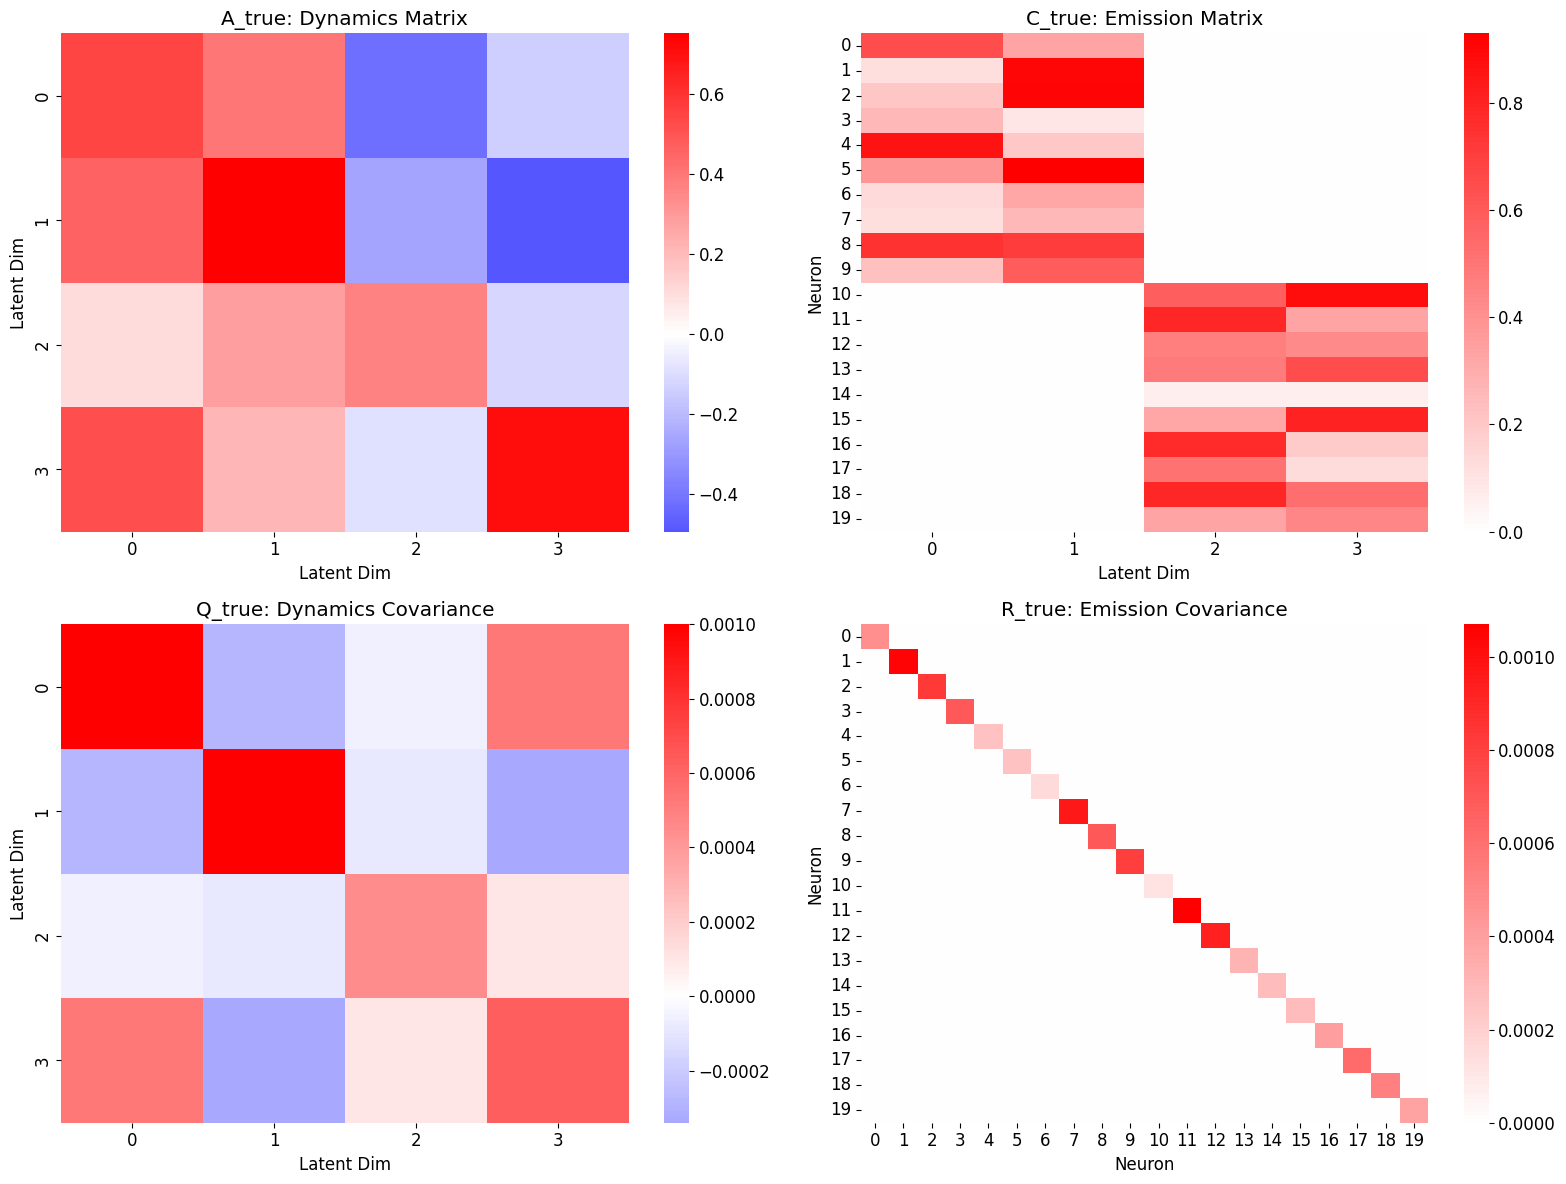

In [19]:
# Define dimensions and structure
D = 4  # Total state dimension
N = 20  # Number of observed neurons
T = 100  # Number of time steps
K = 2  # Number of cell types
key = jr.PRNGKey(0)  # Random key for reproducibility
keys=jr.split(key, 4)
# Step 1: Generate Synthetic Data for Demonstration
print(" STEP 1: GENERATING SYNTHETIC Parameters")
print("=" * 60)

# 3 cell types: excitatory, inhibitory, and modulatory
cell_types = jnp.array([0, 1])
cell_sign = jnp.array([1, -1])
cell_type_dimensions = jnp.array([2, 2])
cell_type_mask = jnp.concatenate([jnp.zeros(10, dtype=jnp.int32), jnp.ones(10, dtype=jnp.int32)])
cell_type_neuron_count = jnp.array([10, 10])
default_config = {
    'cell_type_dimensions': cell_type_dimensions,
    'cell_sign': cell_sign,
    'cell_type_mask': cell_type_mask,
    'cell_type_neuron_count': cell_type_neuron_count
}




#3. Set Parameters
#Set dynamics matrix
dynamics_mask = jnp.repeat(cell_sign, cell_type_dimensions)# Apply Dale's law constraints to create dynamics mask
#A_true = jnp.array(create_dynamics_matrix(cell_type_dimensions, D))
A_true=make_A_true(keys[0], cell_type_dimensions, cell_sign, target_cond=15.0, spectral_radius=0.95)

# Create emission matrix with Dale's law structure
keysC = jr.split(keys[0], len(cell_types))
C_blocks = []
col_start = 0
for i in range(len(cell_types)):
    #get the number of neurons for this cell type
    N_type = jnp.sum(jnp.where(cell_type_mask == cell_types[i], 1, 0))
    D_type = cell_type_dimensions[i]
    C_type=jr.uniform(keysC[i], (N_type, D_type), minval=0.0, maxval=1.0)
    #C_type = generate_nonneg_matrix(keysC[i], N_type, D_type, noise=0.05, col_scale=1.0) *cell_sign[i]
    
    # create padded block: [zeros_left, U, zeros_right]
    left_pad = jnp.zeros((N_type, col_start))
    right_pad = jnp.zeros((N_type, D - col_start - D_type))
    C_blocks.append(jnp.concatenate([left_pad, C_type, right_pad], axis=1))
    col_start += D_type

C_true = jnp.concatenate(C_blocks, axis=0)  #scale down emissions to make it more realistic

Q=jr.normal(keys[1], (D, D))
Q = Q.T@Q + jnp.identity(D)
Q_true=Q/(jnp.max(Q)*1000)
#Q_true = make_Q_true(keys[1], D, target_cond=8.0, scale=6e-3)


# R should be num_neurons x num_neurons, diagonal with positive entries
R_true = jnp.array(np.diag(np.random.rand( N) + 0.1)/1000)
#R=jnp.diag(1/jnp.maximum(1e-4, jnp.linalg.norm(C_true, axis=1))) * 0.1

# check that Q and R are PD
assert jnp.all(jnp.linalg.eigvals(Q_true) > 0), "Q is not PD"
#assert jnp.all(jnp.linalg.eigvals(R_true) > 0), "R is not PD"

#if Q is ill-conditioned, recondition it
if jnp.linalg.cond(Q_true) > 1000:
    Q_true = recondition_Q(Q_true, target_cond=1.0)
#checking condition numbers
print(f"Condition number of A_true: {jnp.linalg.cond(A_true)}")
print(f"Condition number of C_true: {jnp.linalg.cond(C_true)}")
print(f"Condition number of Q_true: {jnp.linalg.cond(Q_true)}")
print(f"Condition number of R_true: {jnp.linalg.cond(R_true)}")
#checking SNR values
print(f"Process SNR: {process_snr_ref(A_true, Q_true):.2f}")
print(f"Observation SNR: {observation_snr(A_true,C_true, Q_true, R_true):.2f}")

#Setting the params
emissions=ParamsCTDSEmissions(weights=C_true, cov=R_true, bias=jnp.zeros(N))
dynamics=ParamsCTDSDynamics(weights=A_true, cov=Q_true, dynamics_mask=dynamics_mask)
initial=ParamsCTDSInitial(mean=jnp.zeros(D), cov=jnp.eye(D) * 0.1)

constraints = ParamsCTDSConstraints(
        cell_types=cell_types,
        cell_sign=cell_sign,
        cell_type_dimensions=cell_type_dimensions,
        cell_type_mask=cell_type_mask
    )
ctds_params= ParamsCTDS(
        emissions=emissions,
        dynamics=dynamics,
        initial=initial,
        constraints=constraints,
        observations=None,  # No observations yet
    )


# Step 2: Visualize the Synthetic Data
%matplotlib inline

# Visualize observations (neurons x 
# Visualize all parameter matrices in subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Visualize A_true (dynamics weights)
sns.heatmap(np.array(A_true), cmap='bwr', center=0, cbar=True, ax=axes[0, 0])
axes[0, 0].set_title('A_true: Dynamics Matrix')
axes[0, 0].set_xlabel('Latent Dim')
axes[0, 0].set_ylabel('Latent Dim')

# Visualize C_true (emission weights)
sns.heatmap(np.array(C_true), cmap='bwr', center=0, cbar=True, ax=axes[0, 1])
axes[0, 1].set_title('C_true: Emission Matrix')
axes[0, 1].set_xlabel('Latent Dim')
axes[0, 1].set_ylabel('Neuron')

# Visualize Q_true (dynamics covariance)
sns.heatmap(np.array(Q_true), cmap='bwr', center=0, cbar=True, ax=axes[1, 0])
axes[1, 0].set_title('Q_true: Dynamics Covariance')
axes[1, 0].set_xlabel('Latent Dim')
axes[1, 0].set_ylabel('Latent Dim')

# Visualize R_true (emission covariance)
sns.heatmap(np.array(R_true), cmap='bwr', center=0, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title('R_true: Emission Covariance')
axes[1, 1].set_xlabel('Neuron')
axes[1, 1].set_ylabel('Neuron')

plt.tight_layout()

## 2. Create CTDS Model

In [20]:

ctds=CTDS(N,cell_types, cell_sign, cell_type_dimensions, cell_type_mask)

#ctds, ctds_params, states, observations= generate_synthetic_ssm(D,N, T, cell_types, cell_sign, cell_type_dimensions, cell_type_mask, jax.random.PRNGKey(42))

"""
states, observations, ctds, ctds_params = generate_synthetic_data(
    num_samples=1,
    num_timesteps=T,
    state_dim=D,
    emission_dim=N,
    cell_types=K
)

#Defining True Params
A_true = ctds_params.dynamics.weights
C_true = ctds_params.emissions.weights
Q_true = ctds_params.dynamics.cov
R_true = ctds_params.emissions.cov
"""
#print(f"Condition number of observations: {jnp.linalg.cond(observations)}")
print(f"Model structure:")
print(f"  State dimension (D): {D}")
print(f"  Observation dimension (N): {N}")
print(f"  Time steps (T): {T}")
print(f"  Cell types: {len(ctds.constraints.cell_types)}")
print(f"  Cell type mask: {ctds.constraints.cell_type_mask}")
print(f"  Cell type dimensions: {ctds.constraints.cell_type_dimensions}")
print(f"  Dynamics mask: {ctds_params.dynamics.dynamics_mask}")


Model structure:
  State dimension (D): 4
  Observation dimension (N): 20
  Time steps (T): 100
  Cell types: 2
  Cell type mask: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
  Cell type dimensions: [2 2]
  Dynamics mask: [ 1  1 -1 -1]


### Generate Observations

In [21]:
# Generate datasets from CTDS model using ground truth parameters
print(" STEP 1b: GENERATING DATASETS FROM CTDS MODEL")
print("=" * 60)
samples=50

datas=[]
states_list = []
keys= jr.split(key, samples)
for i in range(samples): 
    sampled_states, sampled_observations = ctds.sample(ctds_params, key=keys[i], num_timesteps=T)
    states_list.append(sampled_states)
    datas.append(sampled_observations)
#covert to jax array with shape (samples, T, N)
batched_states = jnp.array(states_list)
batched_observations = jnp.array(datas)
observations = batched_observations[0]  # Shape: (T, N)
# Plot all true states in two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = plt.cm.tab10(np.linspace(0, 1, D))

# Left subplot: Individual samples
for dim in range(D):
    for sample in range(min(10, batched_states.shape[0])):
        axes[0].plot(batched_states[sample, :, dim], 
                    color=colors[dim], alpha=0.3, linewidth=0.5)

axes[0].set_title('Individual Sample Trajectories')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('State Value')
axes[0].grid(True, alpha=0.3)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right subplot: Mean trajectories
for dim in range(D):
    mean_trajectory = jnp.mean(batched_states[:, :, dim], axis=0)
    axes[1].plot(mean_trajectory, color=colors[dim], linewidth=2, 
                label=f'Dim {dim+1} (mean)')

axes[1].set_title('Mean State Trajectories')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('State Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

 STEP 1b: GENERATING DATASETS FROM CTDS MODEL


KeyboardInterrupt: 

## 3. Initialize and Fit CTDS Model

Initialize the model from observations and fit using EM algorithm.

In [ ]:
# divide into train and test datasets
num_train_trials = int(0.8*sample)
test_datas = batched_observations[:num_train_trials]
train_datas = batched_observations[num_train_trials:]

#update inital params
m1=jnp.mean(batched_states[:,0,:], axis=0)
X_c=batched_states[:,0,:]-m1
V1=(X_c.T @X_c)/jnp.maximum(batched_states.shape[0]-1, 1)
V1=V1+ 1e-6*jnp.eye(D)
inital=ParamsCTDSInitial(mean=m1, cov=V1)
ctds_params= ParamsCTDS(initial=inital, dynamics=ctds_params.dynamics, emissions=ctds_params.emissions, constraints=ctds_params.constraints, observations=jnp.mean(train_datas, axis=0))


#train_obs=jnp.mean(train_datas, axis=0)
#test_obs=jnp.mean(test_datas, axis=0)
print(f"Train obs shape: {train_datas.shape}, Test obs shape: {test_datas.shape}")

# compute LLs for the test and train datasets
vmap_log_prob = jax.vmap(ctds.marginal_log_prob, in_axes=(None, 0))
true_model_train_ll = jnp.mean(vmap_log_prob(ctds_params, train_datas))
true_model_test_ll = jnp.mean(vmap_log_prob(ctds_params, test_datas))

#true_model_train_ll = ctds.log_prob(ctds_params,jnp.mean(batched_states[:num_train_trials], axis=0), jnp.mean(train_datas, axis=0))
#true_model_test_ll = ctds.log_prob(ctds_params,jnp.mean(batched_states[num_train_trials:], axis=0), jnp.mean(test_datas, axis=0))
print("Train ll:", true_model_train_ll/T)
print("Test ll:",true_model_test_ll/T)


Train obs shape: (43, 100, 20), Test obs shape: (7, 100, 20)
Train ll: 44.92835465922879
Test ll: 45.02072419819885


### Compute True-Model Baselines and Initialize CTDS

Split observations 80/20 train/test. Compute oracle log-likelihoods using the **ground-truth** parameters on both splits — these serve as upper-bound baselines for the fitted model. Then initialize CTDS parameters from the training data using NMF-based initialization.

In [ ]:

# Step 2: Model Fitting 
print("\nSTEP 2: MODEL FITTING WITH EM ALGORITHM")
print("=" * 60)


print(" Initializing model parameters...")
start_time = time.time()

# Initialize parameters from observations
#demo_params_init = ctds.initialize(jnp.mean(train_datas, axis=0))
demo_params_init = ctds.initialize(train_datas)

init_time = time.time() - start_time

print(f"✅ Initialization completed in {init_time:.2f} seconds")




STEP 2: MODEL FITTING WITH EM ALGORITHM
 Initializing model parameters...
Y shape (4300, 20)
✅ Initialization completed in 5.44 seconds


### Save Parameters to Disk

Ground-truth parameters and the NMF-initialized parameters are saved to `benchmark_results.pkl` so the SSM comparison section below can reload them without re-running the full generation step.

In [ ]:
#compute LL of initialized model
init_model_train_ll = jnp.mean(vmap_log_prob(demo_params_init, train_datas))
print(f"Initial model train LL: {init_model_train_ll/T:.4f}")

#save as pickle so we can use these same parameters elsewhere
save_dir = "/Users/kash/Documents/PNI/Cell_type_dynamical_system"
os.makedirs(save_dir, exist_ok=True)
true_params = {
    "A_true": np.array(A_true),
    "C_true": np.array(C_true),
    "Q_true": np.array(Q_true),
    "R_true": np.array(R_true),
    "train_datas": np.array(train_datas),
    "test_datas": np.array(test_datas),
    "train_ll": float(true_model_train_ll),
    "test_ll": float(true_model_test_ll),
    "states": np.array(batched_states),
}

with open(os.path.join(save_dir, "true_params.pkl"), "wb") as f:
    pickle.dump(true_params, f)
#Save initialized params
os.makedirs(save_dir, exist_ok=True)
init_params = {
    "A_init": np.array(demo_params_init.dynamics.weights),
    "C_init": np.array(demo_params_init.emissions.weights),
    "Q_init": np.array(demo_params_init.dynamics.cov),
    "R_init": np.array(demo_params_init.emissions.cov),
    "init_cov": np.array(demo_params_init.initial.cov),
    "init_ll": float(init_model_train_ll),
}

with open(os.path.join(save_dir, "init_params.pkl"), "wb") as f:
    pickle.dump(init_params, f)


Initial model train LL: 19.6566


### Run EM Algorithm

Run `fit_em` on the training set for the configured number of iterations. After convergence, the Kalman smoother computes the posterior latent state estimates used for trajectory recovery below.

In [ ]:
# Fit model using EM algorithm
print(" Running EM algorithm...")
num_em_iters = 100

emissions=ParamsCTDSEmissions(weights=C_true, cov=R_true,bias=demo_params_init.emissions.bias, emission_dims=demo_params_init.emissions.emission_dims, left_padding_dims=demo_params_init.emissions.left_padding_dims, right_padding_dims=demo_params_init.emissions.right_padding_dims)
ctds_params= ParamsCTDS(initial=ctds_params.initial, dynamics=ctds_params.dynamics, emissions=emissions, constraints=ctds_params.constraints, observations=jnp.mean(train_datas, axis=0))# Set observations for EM fitting


# Track timing
em_start_time = time.time()

# Run EM fitting with progress tracking 
# Refit on training data
params_fitted, test_lls = ctds.fit_em(
    demo_params_init, 
    train_datas, 
    num_iters=num_em_iters
)

em_total_time = time.time() - em_start_time
em_per_iter_time = em_total_time / num_em_iters
from ctds.inference import DynamaxLGSSMBackend
print(f"\n✅ EM Algorithm Results:")
print(f"  • Total fitting time: {em_total_time:.2f} seconds")
print(f"  • Time per iteration: {em_per_iter_time:.3f} seconds")
print(f"  • Initial log-likelihood: {test_lls[0]:.2f}")
print(f"  • Final log-likelihood: {test_lls[-1]:.2f}")
print(f"  • Log-likelihood improvement: {test_lls[-1] - test_lls[0]:.2f}")


# Compute latent states using smoother
print("\n🔍 Computing fitted latent trajectories...")
smoothed_means, smoothed_covariances = DynamaxLGSSMBackend.smoother(params_fitted, observations)
states_fitted = smoothed_means #shape (T, D)

print(f"  • Fitted states shape: {states_fitted.shape}")
print(f"  • Smoothing completed successfully!")


 Running EM algorithm...


Running for 100 iterations:   0%|          | 0/100 [00:00<?, ?it/s]


✅ EM Algorithm Results:
  • Total fitting time: 3.85 seconds
  • Time per iteration: 0.038 seconds
  • Initial log-likelihood: 19.66
  • Final log-likelihood: 44.88
  • Log-likelihood improvement: 25.23

🔍 Computing fitted latent trajectories...
  • Fitted states shape: (100, 4)
  • Smoothing completed successfully!


## 4. Evaluate Model Performance on Hold-out Data

Compute the marginal log-likelihood of the **held-out** test set under the fitted model and compare it to the oracle (true-parameter) upper bound. The LL gap (in % of the oracle value) quantifies information lost to finite data and EM approximation.

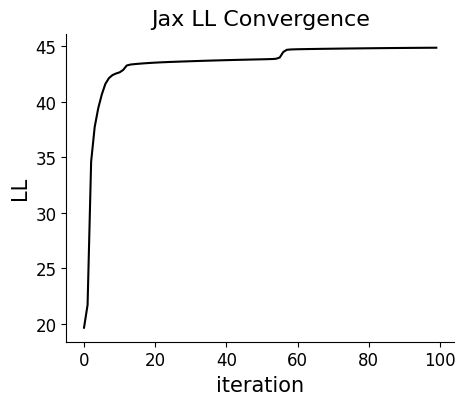

/var/folders/wp/bdnctj2s0s52y843dzp1kq_h0000gn/T/ipykernel_4203/2719738227.py:48: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show()


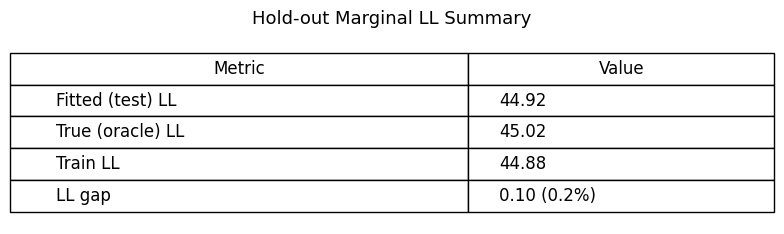

In [ ]:
vmap_marginal_ll = jax.vmap(ctds.marginal_log_prob, in_axes=(None, 0))
fitted_trial_lls = vmap_marginal_ll(params_fitted, test_datas)   # (n_test,)
true_trial_lls   = vmap_marginal_ll(ctds_params, test_datas)   # oracle upper bound
train_trial_lls  = vmap_marginal_ll(params_fitted, train_datas)  # overfitting check

fitted_test_ll = jnp.mean(fitted_trial_lls)/T
true_test_ll   = jnp.mean(true_trial_lls)/T
train_ll       = jnp.mean(train_trial_lls)/T
ll_gap     = true_test_ll - fitted_test_ll
ll_gap_pct = ll_gap / jnp.abs(true_test_ll) * 100
"""
print("─── Hold-out Marginal LL ───────────────────────────")
print(f"  Fitted (test):    {fitted_test_ll:.2f} ")
print(f"  True   (oracle):  {true_test_ll:.2f}")
print(f"  Train  LL:        {train_ll:.2f}")
print(f"  LL gap:           {ll_gap:.2f}  ({ll_gap_pct:.1f}% of true LL)")
"""
#plot logs
plt.figure(figsize=(5, 4))
plt.title('Jax LL Convergence', fontsize=16)  # add this line
plt.plot(test_lls, color = 'k')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.ylabel('LL', fontsize=15)
plt.xlabel('iteration', fontsize=15)
#plt.savefig(os.path.join(_EXP0_FIG_DIR, "ll_convergence.png"), dpi=300, bbox_inches='tight')
plt.show()

fig2, ax_table = plt.subplots(figsize=(8, 2.5))  # wider figure too
ax_table.axis('off')
table_data = [
    ["Fitted (test) LL",  f"{fitted_test_ll:.2f}"],
    ["True (oracle) LL",  f"{true_test_ll:.2f}"],
    ["Train LL",          f"{test_lls[-1]:.2f}"],
    ["LL gap",            f"{ll_gap:.2f} ({ll_gap_pct:.1f}%)"],
]
tab = ax_table.table(
    cellText=table_data,
    colLabels=["Metric", "Value"],
    loc='center',
    cellLoc='left',
    colWidths=[0.6, 0.4],  
)
tab.scale(1, 2)  # (x_scale, y_scale) — increase y to add row height
ax_table.set_title("Hold-out Marginal LL Summary", fontsize=13, pad=12)
fig2.tight_layout()
#fig2.savefig(os.path.join(_EXP0_FIG_DIR, "ll_summary_table.png"), dpi=300, bbox_inches='tight')
fig2.show()

### Parameter Recovery Errors (Before Alignment)

Frobenius-norm errors between fitted and ground-truth parameter matrices.  
**Note:** these numbers ignore the within-block permutation gauge freedom, so they may appear artificially large. The next section aligns the parameters first before computing final errors.

Computing accuracy metrics...
✅ Accuracy Metrics:

Absolute Frobenius Errors:
  Dynamics (A):     0.6617
  Emissions (C):    2.1879
  Process noise (Q): 0.0161
  Obs noise (R):    0.0001

Relative Errors (%):
  Dynamics (A):     39.31%
  Emissions (C):    64.47%
  Process noise (Q): 850.87%
  Obs noise (R):    3.66%


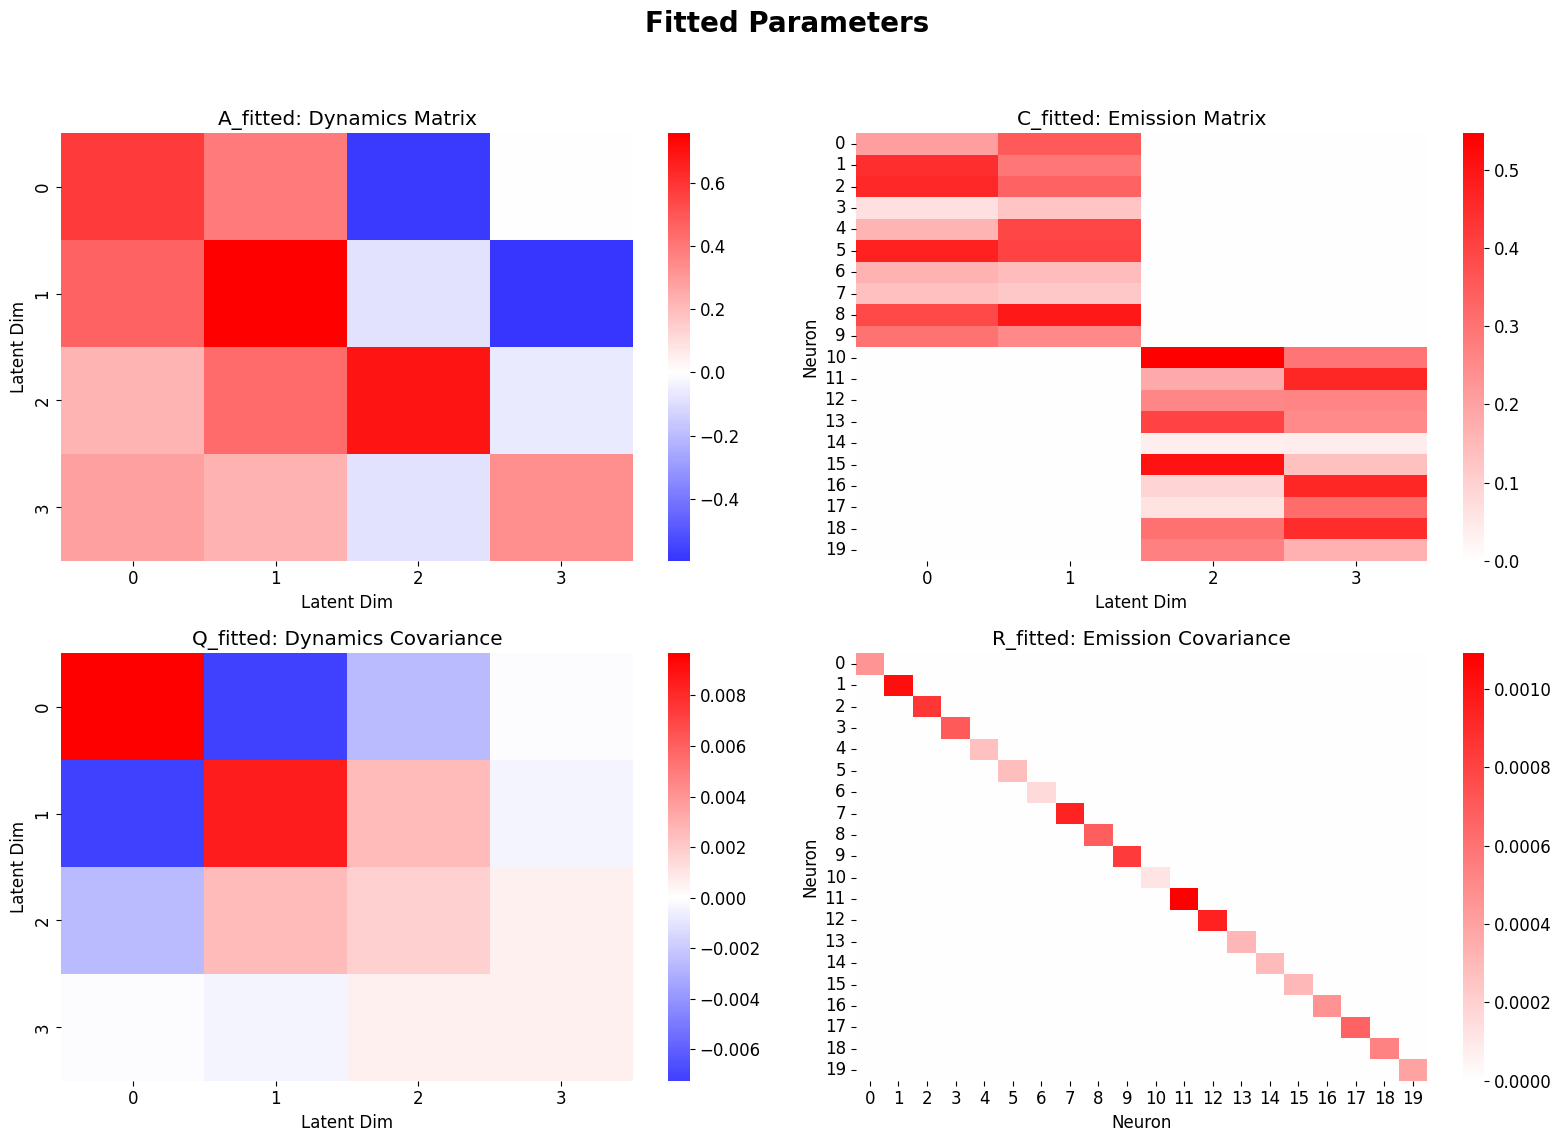

In [ ]:
# Compute accuracy metrics
print("Computing accuracy metrics...")
#C_rec, A_rec, Q_rec= transform_true_rec(C_true, params_fitted.emissions.weights, params_fitted.dynamics.weights, params_fitted.dynamics.cov, ctds.constraints.cell_type_dimensions)
# Frobenius norm errors for matrices
A_error = jnp.linalg.norm(params_fitted.dynamics.weights - A_true, 'fro')
C_error = jnp.linalg.norm(params_fitted.emissions.weights - C_true, 'fro')
Q_error = jnp.linalg.norm(params_fitted.dynamics.cov - Q_true, 'fro')
R_error = jnp.linalg.norm(params_fitted.emissions.cov - R_true, 'fro')

# Relative errors (normalized by true parameter magnitude)
A_rel_error = A_error / jnp.linalg.norm(A_true, 'fro')
C_rel_error = C_error / jnp.linalg.norm(C_true, 'fro')
Q_rel_error = Q_error / jnp.linalg.norm(Q_true, 'fro')
R_rel_error = R_error / jnp.linalg.norm(R_true, 'fro')

print("✅ Accuracy Metrics:")
print(f"\nAbsolute Frobenius Errors:")
print(f"  Dynamics (A):     {A_error:.4f}")
print(f"  Emissions (C):    {C_error:.4f}")
print(f"  Process noise (Q): {Q_error:.4f}")
print(f"  Obs noise (R):    {R_error:.4f}")

print(f"\nRelative Errors (%):")
print(f"  Dynamics (A):     {A_rel_error*100:.2f}%")
print(f"  Emissions (C):    {C_rel_error*100:.2f}%")
print(f"  Process noise (Q): {Q_rel_error*100:.2f}%")
print(f"  Obs noise (R):    {R_rel_error*100:.2f}%")



# Visualize all parameter matrices in subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Fitted Parameters ", fontsize=20, fontweight='bold')
# Visualize A_fitted (dynamics weights)
sns.heatmap(np.array(params_fitted.dynamics.weights), cmap='bwr', center=0, cbar=True, ax=axes[0, 0])
axes[0, 0].set_title('A_fitted: Dynamics Matrix')
axes[0, 0].set_xlabel('Latent Dim')
axes[0, 0].set_ylabel('Latent Dim')

# Visualize C_fitted (emission weights)
sns.heatmap(np.array(params_fitted.emissions.weights), cmap='bwr', center=0, cbar=True, ax=axes[0, 1])
axes[0, 1].set_title('C_fitted: Emission Matrix')
axes[0, 1].set_xlabel('Latent Dim')
axes[0, 1].set_ylabel('Neuron')

# Visualize Q_fitted (dynamics covariance)
sns.heatmap(np.array(params_fitted.dynamics.cov), cmap='bwr', center=0, cbar=True, ax=axes[1, 0])
axes[1, 0].set_title('Q_fitted: Dynamics Covariance')
axes[1, 0].set_xlabel('Latent Dim')
axes[1, 0].set_ylabel('Latent Dim')

# Visualize R_fitted (emission covariance)
sns.heatmap(np.array(params_fitted.emissions.cov), cmap='bwr', center=0, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title('R_fitted: Emission Covariance')
axes[1, 1].set_xlabel('Neuron')
axes[1, 1].set_ylabel('Neuron')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


### Align Recovered Parameters to Ground Truth

`transform_true_rec_hungarian` uses the Hungarian algorithm to find the optimal column permutation **within each cell-type block** (E and I separately), then reorders rows/columns of A, C, and Q consistently. After alignment, the Frobenius errors are the true recovery metrics.

In [ ]:
from ctds.simulation_utils import transform_true_rec_hungarian
list_of_dims_2d = cell_type_dimensions[None, :]  # shape (1, 2)
align_result = transform_true_rec_hungarian(
    C_true=np.array(C_true),
    C_rec=np.array(params_fitted.emissions.weights),
    A_rec=np.array(params_fitted.dynamics.weights),
    Q_rec=np.array(params_fitted.dynamics.cov),
    list_of_dimensions=np.array(list_of_dims_2d),   # e.g. shape (1, 2) or (num_regions, num_cell_types)
    region_identity=None,                              # or your region vector
    dead_thresh=1e-6,
    use_abs_corr=True,
    verbose=True,
)

if align_result["collapsed"]:
    err_A = np.nan
    err_C = np.nan
    collapse_reason = align_result["reason"]
    print("Alignment skipped:", collapse_reason)
else:
    C_aligned = align_result["C_aligned"]
    A_aligned = align_result["A_aligned"]
    Q_aligned = align_result["Q_aligned"]

    err_A = np.linalg.norm(A_aligned - np.array(A_true), ord="fro")
    err_C = np.linalg.norm(C_aligned - np.array(C_true), ord="fro")
    print(err_A)
    print(err_C)

params_recovered = ParamsCTDS(
    emissions=ParamsCTDSEmissions(weights=C_aligned, cov=params_fitted.emissions.cov, bias=demo_params_init.emissions.bias, emission_dims=demo_params_init.emissions.emission_dims, left_padding_dims=demo_params_init.emissions.left_padding_dims, right_padding_dims=demo_params_init.emissions.right_padding_dims),
    dynamics=ParamsCTDSDynamics(weights=A_aligned, cov=Q_aligned, dynamics_mask=demo_params_init.dynamics.dynamics_mask),
    initial=params_fitted.initial,
    constraints=demo_params_init.constraints,
    observations=demo_params_init.observations
)

[align] region=0, neurons=20, latent_dims=4
[align] region=0, cell_type=0, corr=
[[0.544 0.872]
 [0.995 0.836]]
[align] region=0, cell_type=0, assignment true->rec = [(0, 1), (1, 0)]
[align] region=0, cell_type=1, corr=
[[0.646 0.996]
 [0.999 0.613]]
[align] region=0, cell_type=1, assignment true->rec = [(0, 1), (1, 0)]
0.6588501209683812
0.6134295101104054


## 5. Parameter Recovery After Alignment

Side-by-side heatmaps (true vs. aligned recovered, shared colorscale per matrix pair) and a summary bar chart of **relative Frobenius errors** for A (dynamics), C (emissions), Q (process noise), and R (observation noise).  
Threshold: ≤20% = good recovery, ≤100% = partial recovery.

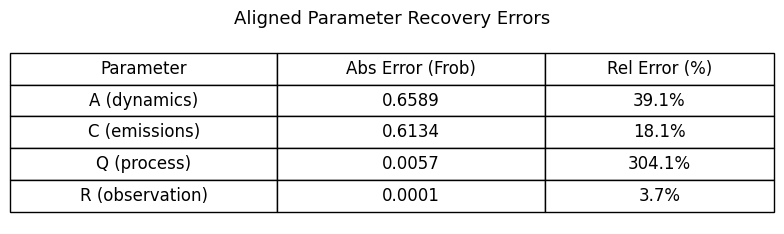

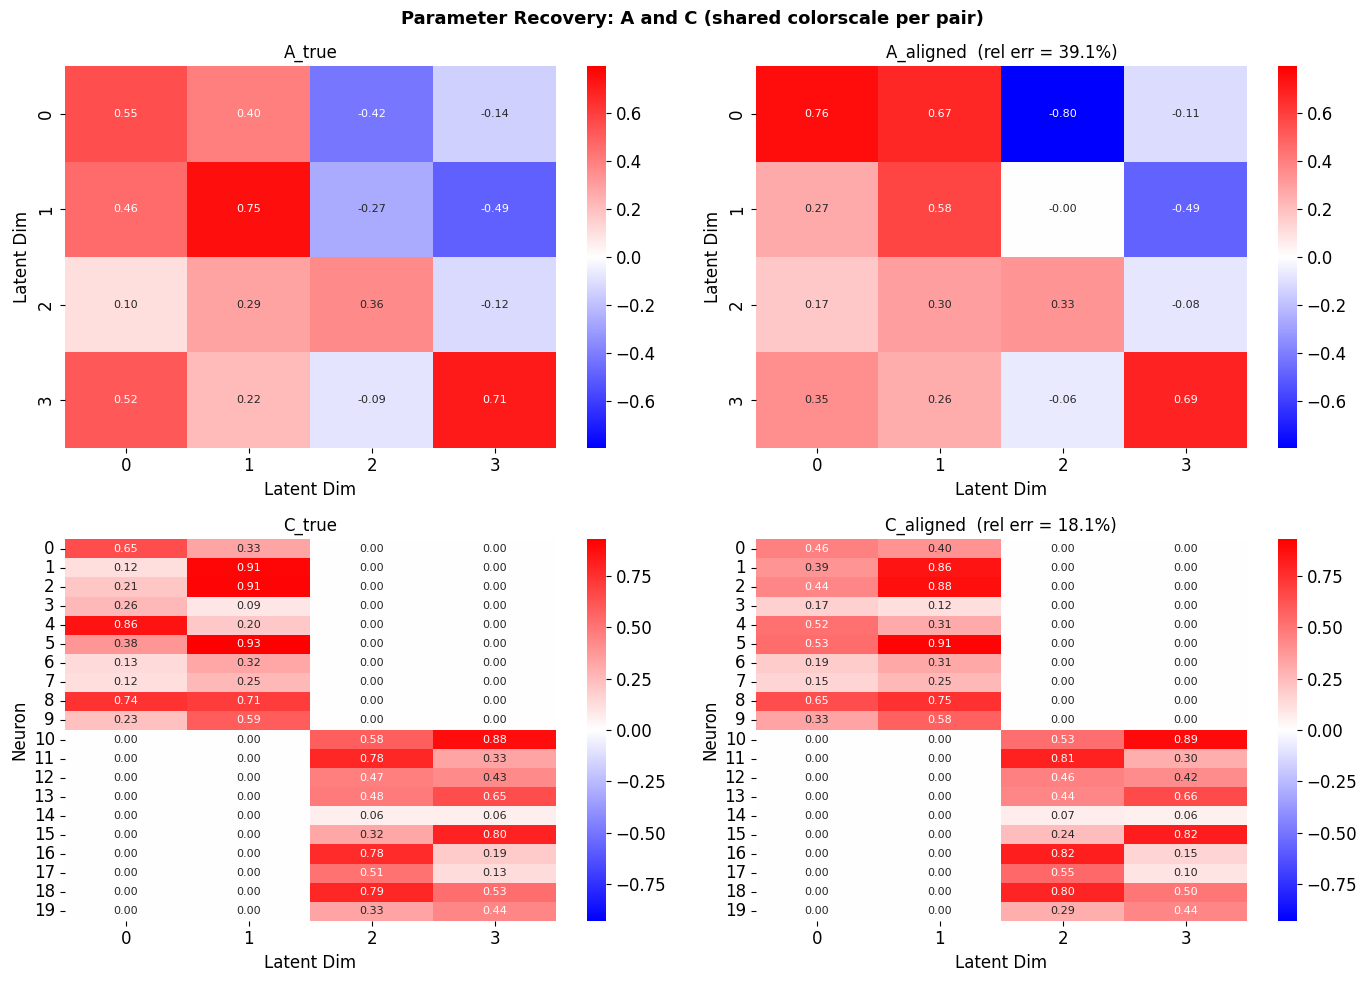

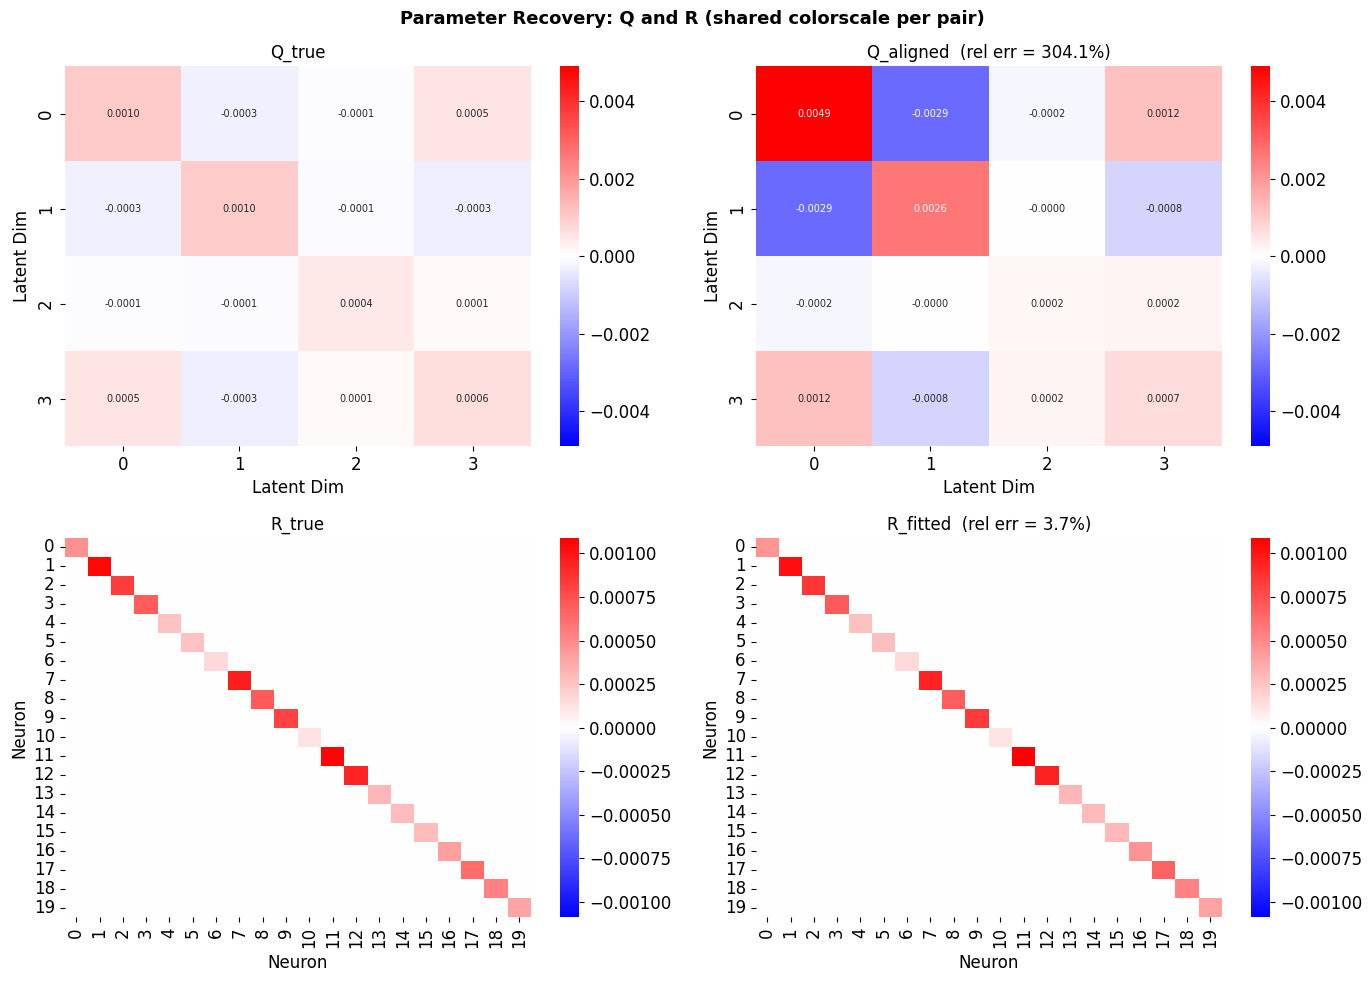

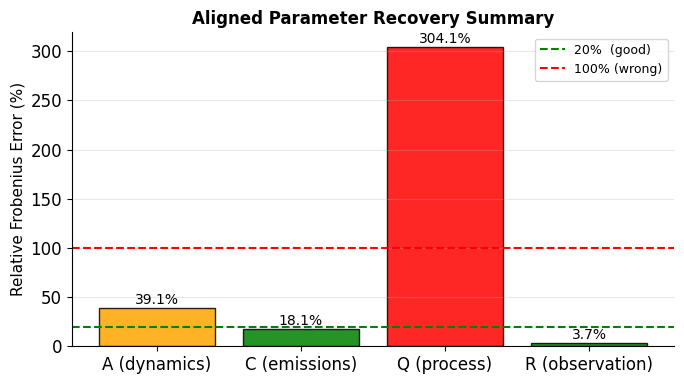

In [ ]:
# ============================================================================
# SECTION 2: PARAMETER RECOVERY (after alignment)
# ============================================================================
# Requires: A_aligned, C_aligned, Q_aligned from transform_true_rec cell

# --- 2a. Frobenius errors on ALIGNED parameters ---
def frob_errors(true, aligned):
    abs_err = float(jnp.linalg.norm(aligned - true, 'fro'))
    rel_err = abs_err / float(jnp.linalg.norm(true, 'fro'))
    return abs_err, rel_err

abs_A, r_A = frob_errors(A_true, A_aligned)
abs_C, r_C = frob_errors(C_true, C_aligned)
abs_Q, r_Q = frob_errors(Q_true, Q_aligned)
abs_R, r_R = frob_errors(R_true, params_fitted.emissions.cov)

fig_tbl, ax_tbl = plt.subplots(figsize=(8, 2.5))
ax_tbl.axis('off')
table_data = [
    ["A (dynamics)",    f"{abs_A:.4f}", f"{r_A*100:.1f}%"],
    ["C (emissions)",   f"{abs_C:.4f}", f"{r_C*100:.1f}%"],
    ["Q (process)",     f"{abs_Q:.4f}", f"{r_Q*100:.1f}%"],
    ["R (observation)", f"{abs_R:.4f}", f"{r_R*100:.1f}%"],
]
tab = ax_tbl.table(
    cellText=table_data,
    colLabels=["Parameter", "Abs Error (Frob)", "Rel Error (%)"],
    loc='center', cellLoc='center',
    colWidths=[0.35, 0.35, 0.3],
)
tab.scale(1, 2)
ax_tbl.set_title("Aligned Parameter Recovery Errors", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# --- 2b. Side-by-side heatmaps: A and C ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vmax_A = float(jnp.max(jnp.abs(jnp.stack([A_true, A_aligned]))))
sns.heatmap(np.array(A_true),    cmap='bwr', center=0, vmin=-vmax_A, vmax=vmax_A,
            cbar=True, ax=axes[0, 0], annot=True, fmt='.2f', annot_kws={'size': 8})
axes[0, 0].set_title('A_true', fontsize=12)
axes[0, 0].set_xlabel('Latent Dim'); axes[0, 0].set_ylabel('Latent Dim')

sns.heatmap(np.array(A_aligned), cmap='bwr', center=0, vmin=-vmax_A, vmax=vmax_A,
            cbar=True, ax=axes[0, 1], annot=True, fmt='.2f', annot_kws={'size': 8})
axes[0, 1].set_title(f'A_aligned  (rel err = {r_A*100:.1f}%)', fontsize=12)
axes[0, 1].set_xlabel('Latent Dim'); axes[0, 1].set_ylabel('Latent Dim')

vmax_C = float(jnp.max(jnp.abs(jnp.stack([C_true, C_aligned]))))
sns.heatmap(np.array(C_true),    cmap='bwr', center=0, vmin=-vmax_C, vmax=vmax_C,
            cbar=True, ax=axes[1, 0], annot=True, fmt='.2f', annot_kws={'size': 8})
axes[1, 0].set_title('C_true', fontsize=12)
axes[1, 0].set_xlabel('Latent Dim'); axes[1, 0].set_ylabel('Neuron')

sns.heatmap(np.array(C_aligned), cmap='bwr', center=0, vmin=-vmax_C, vmax=vmax_C,
            cbar=True, ax=axes[1, 1],  annot=True, fmt='.2f', annot_kws={'size': 8})
axes[1, 1].set_title(f'C_aligned  (rel err = {r_C*100:.1f}%)', fontsize=12)
axes[1, 1].set_xlabel('Latent Dim'); axes[1, 1].set_ylabel('Neuron')

plt.suptitle('Parameter Recovery: A and C (shared colorscale per pair)', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig(os.path.join(_EXP0_FIG_DIR, "param_recovery_a_c.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- 2c. Side-by-side heatmaps: Q and R ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vmax_Q = float(jnp.max(jnp.abs(jnp.stack([Q_true, Q_aligned]))))
sns.heatmap(np.array(Q_true),  cmap='bwr', center=0, vmin=-vmax_Q, vmax=vmax_Q,
            cbar=True, ax=axes[0, 0], annot=True, fmt='.4f', annot_kws={'size': 7})
axes[0, 0].set_title('Q_true', fontsize=12)
axes[0, 0].set_xlabel('Latent Dim'); axes[0, 0].set_ylabel('Latent Dim')

sns.heatmap(np.array(Q_aligned), cmap='bwr', center=0, vmin=-vmax_Q, vmax=vmax_Q,
            cbar=True, ax=axes[0, 1], annot=True, fmt='.4f', annot_kws={'size': 7})
axes[0, 1].set_title(f'Q_aligned  (rel err = {r_Q*100:.1f}%)', fontsize=12)
axes[0, 1].set_xlabel('Latent Dim'); axes[0, 1].set_ylabel('Latent Dim')

vmax_R = float(jnp.max(jnp.abs(jnp.stack([R_true, params_fitted.emissions.cov]))))
sns.heatmap(np.array(R_true),    cmap='bwr', center=0, vmin=-vmax_R, vmax=vmax_R,
            cbar=True, ax=axes[1, 0])
axes[1, 0].set_title('R_true', fontsize=12)
axes[1, 0].set_xlabel('Neuron'); axes[1, 0].set_ylabel('Neuron')

sns.heatmap(np.array(params_fitted.emissions.cov), cmap='bwr', center=0, vmin=-vmax_R, vmax=vmax_R,
            cbar=True, ax=axes[1, 1])
axes[1, 1].set_title(f'R_fitted  (rel err = {r_R*100:.1f}%)', fontsize=12)
axes[1, 1].set_xlabel('Neuron'); axes[1, 1].set_ylabel('Neuron')

plt.suptitle('Parameter Recovery: Q and R (shared colorscale per pair)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(_EXP0_FIG_DIR, "param_recovery_q_r.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- 2d. Summary bar chart ---
fig, ax = plt.subplots(figsize=(7, 4))
labels  = ['A (dynamics)', 'C (emissions)', 'Q (process)', 'R (observation)']
rel_errs = [r_A * 100, r_C * 100, r_Q * 100, r_R * 100]
bar_colors = ['green' if v < 20 else ('orange' if v < 100 else 'red') for v in rel_errs]
bars = ax.bar(labels, rel_errs, color=bar_colors, alpha=0.85, edgecolor='k')
ax.axhline(20,  color='green',  linestyle='--', lw=1.5, label='20%  (good)')
ax.axhline(100, color='red',    linestyle='--', lw=1.5, label='100% (wrong)')
for bar, v in zip(bars, rel_errs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Relative Frobenius Error (%)', fontsize=11)
ax.set_title('Aligned Parameter Recovery Summary', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(_EXP0_FIG_DIR, "param_recovery_summary.png"), dpi=300, bbox_inches='tight')
plt.show()

## 6. Latent Trajectory Recovery

Apply the Kalman smoother with the aligned fitted parameters and compare the resulting latent state estimates to the ground-truth trajectories.

**Metrics:** per-dimension R² (1.0 = perfect), mean squared error, and per-neuron observation prediction R². R² is computed separately for excitatory and inhibitory latent dimensions.

In [ ]:
# Compute latent trajectory recovery
print("Computing latent trajectory metrics...")
states_true=batched_states[:num_train_trials].reshape(-1, D)
# Run smoother to get fitted latent states
vmap_smoother = jax.vmap(ctds.smoother, in_axes=(None, 0))
posterior = vmap_smoother(params_recovered, train_datas)
states_fitted = posterior[0].reshape(-1, D)
print(states_fitted.shape, states_true.shape)
# Latent trajectory MSE
latent_mse = jnp.mean((states_fitted - states_true)**2)

# R² for latent trajectories (per dimension)
def compute_r_squared(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred)**2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

latent_r2_per_dim = jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(D)
])
latent_r2_avg = jnp.mean(latent_r2_per_dim)
I_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(cell_type_dimensions[0],cell_type_dimensions[0]+cell_type_dimensions[1])
]))
E_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(cell_type_dimensions[0])
]))

# Prediction R² for observations
#observations=batched_observations.reshape(batched_observations.shape[0]*batched_observations.shape[1], batched_observations.shape[2])   #(T_total, N)  
observations=train_datas.reshape(train_datas.shape[0]*train_datas.shape[1], train_datas.shape[2])
observations_pred = states_fitted @ params_fitted.emissions.weights.T
obs_r2_per_neuron = jnp.array([
    compute_r_squared(train_datas.reshape(train_datas.shape[0]*train_datas.shape[1], train_datas.shape[2])[:, i], observations_pred[:, i])
    for i in range(N)
])
obs_r2_avg = jnp.mean(obs_r2_per_neuron)

print("✅ Trajectory Recovery Metrics:")
print(f"  Latent MSE:           {latent_mse:.6f}")
print(f"  Latent R² (avg):      {latent_r2_avg:.4f}")
print(f"  Latent R² (per dim):  {latent_r2_per_dim}")
print(f"  Latent R² (I avg):    {I_latent_r2_avg:.4f}")
print(f"  Latent R² (E avg):    {E_latent_r2_avg:.4f}")

print(f"  Observation R² (avg): {obs_r2_avg:.4f}")
print(f"  Obs R² range:         [{jnp.min(obs_r2_per_neuron):.3f}, {jnp.max(obs_r2_per_neuron):.3f}]")


# Latent trajectory comparison
ncols = 2
nrows = (D + ncols - 1) // ncols   # ceiling division → enough rows for all D dims
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

# Plot first 6 dimensions (all dimensions in our case)
time_points = jnp.arange(states_fitted.shape[0])
colors = plt.cm.Set1(np.linspace(0, 1, D))

for i in range(D):
    ax = axes[i]
    
    # Plot true and fitted trajectories
    ax.plot(time_points, states_true[:, i], color=colors[i], linewidth=2, 
           label=f'True (Dim {i+1})', alpha=0.8)
    ax.plot(time_points, states_fitted[:, i], color=colors[i], linewidth=2, 
           linestyle='--', label=f'Fitted (Dim {i+1})', alpha=0.8)
    
    # Add R² score
    r2_score = latent_r2_per_dim[i]
    ax.text(0.02, 0.98, f'R² = {r2_score:.3f}', transform=ax.transAxes, 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time')
    ax.set_ylabel(f'State {i+1}')
    ax.set_title(f'Latent Dimension {i+1} {"(Excitatory)" if i < 3 else "(Inhibitory)"}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Latent Trajectory Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(_EXP0_FIG_DIR, "latent_trajectory_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()


# Residual analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.tab10(np.linspace(0, 1, D))

# Latent residuals E cells
latent_residuals = states_fitted - states_true
for i in range(cell_type_dimensions[0]):
    axes[0, 0].plot(latent_residuals[:, i], label=f'Dim {i+1}', alpha=0.7, color=colors[i])
axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0, 0].set_title('Excitatory Latent State Residuals Over Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residual (Fitted - True)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#Latent residuals I cells
for i in range(cell_type_dimensions[0], cell_type_dimensions[0] + cell_type_dimensions[1]):
    axes[0, 1].plot(latent_residuals[:, i], label=f'Dim {i+1}', alpha=0.7, color=colors[i])
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0, 1].set_title('Inhibitory Latent State Residuals Over Time')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Residual (Fitted - True)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
# Match axis limits to the larger range
xlim = (min(axes[0,0].get_xlim()[0], axes[0,1].get_xlim()[0]),
        max(axes[0,0].get_xlim()[1], axes[0,1].get_xlim()[1]))
ylim = (min(axes[0,0].get_ylim()[0], axes[0,1].get_ylim()[0]),
        max(axes[0,0].get_ylim()[1], axes[0,1].get_ylim()[1]))

axes[0,0].set_xlim(xlim); axes[0,0].set_ylim(ylim)
axes[0,1].set_xlim(xlim); axes[0,1].set_ylim(ylim)
fig.suptitle('Latent State Residuals Over Time', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(_EXP0_FIG_DIR, "latent_residuals_over_time.png"), dpi=300, bbox_inches='tight')

# Observation residuals over time
obs_residuals = observations_pred - observations
"""
axes[0, 1].plot(jnp.mean(jnp.abs(obs_residuals), axis=1), color='red', linewidth=2)
axes[0, 1].set_title('Mean Absolute Observation Residuals')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Mean |Residual|')
axes[0, 1].grid(True, alpha=0.3)
"""
# Residual distributions
axes[1, 0].hist(latent_residuals.flatten(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Latent Residual Distribution')
axes[1, 0].set_xlabel('Residual Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(obs_residuals.flatten(), bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Observation Residual Distribution')
axes[1, 1].set_xlabel('Residual Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('Residual Analysis for Latent Trajectory Recovery', fontsize=13, fontweight='bold')
plt.savefig(os.path.join(_EXP0_FIG_DIR, "latent_residual_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✅ Latent trajectory comparison plots created")

Computing latent trajectory metrics...
(4300, 4) (700, 4)


TypeError: sub got incompatible shapes for broadcasting: (4300, 4), (700, 4).

## 7. Numerical Stability Analysis

Eigenvalue spectrum of the fitted vs. ground-truth dynamics matrix A — all eigenvalues must lie **inside** the unit circle for the model to be stable. Also plots condition numbers and eigenvalues of the noise covariance matrices Q and R, which diagnose near-singular updates during EM.

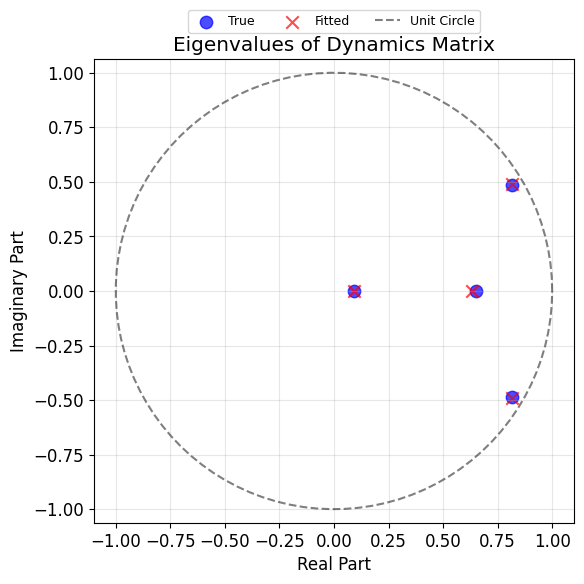

/Users/kash/Documents/Music/enter/lib/python3.10/site-packages/matplotlib/transforms.py:762: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


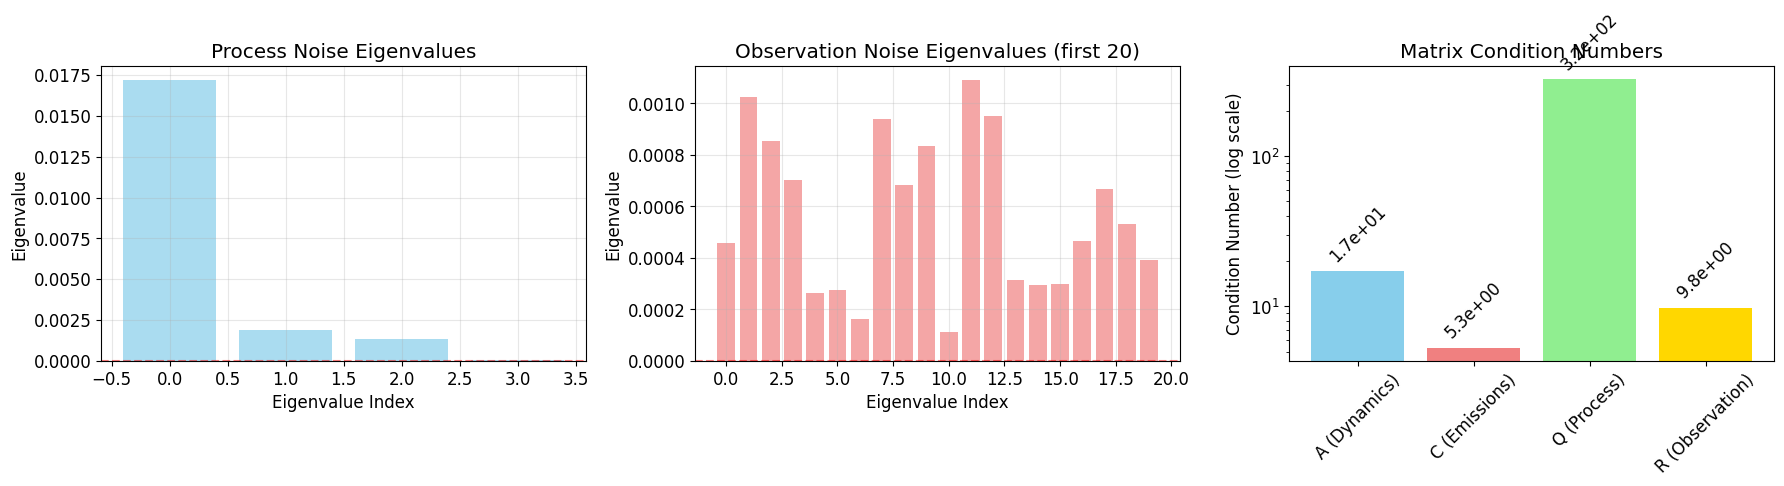

✅ Numerical stability visualization created


In [ ]:
# --- Figure 1: Eigenvalues of Dynamics Matrix ---
fig_eig, ax_eig = plt.subplots(figsize=(6, 6))
A_fitted=params_fitted.dynamics.weights
Q_fitted=params_fitted.dynamics.cov
R_fitted=params_fitted.emissions.cov
eigenvals_true = jnp.linalg.eigvals(A_true)
eigenvals_fitted = jnp.linalg.eigvals(A_fitted)

ax_eig.scatter(jnp.real(eigenvals_true), jnp.imag(eigenvals_true),
               c='blue', s=80, label='True', alpha=0.7, marker='o')
ax_eig.scatter(jnp.real(eigenvals_fitted), jnp.imag(eigenvals_fitted),
               c='red', s=80, label='Fitted', alpha=0.7, marker='x')

theta = jnp.linspace(0, 2*jnp.pi, 100)
ax_eig.plot(jnp.cos(theta), jnp.sin(theta), 'k--', alpha=0.5, label='Unit Circle')
ax_eig.set_xlabel('Real Part')
ax_eig.set_ylabel('Imaginary Part')
ax_eig.set_title('Eigenvalues of Dynamics Matrix')
ax_eig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12),
              ncol=3, fontsize=9, frameon=True)
ax_eig.grid(True, alpha=0.3)
ax_eig.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(_EXP0_FIG_DIR, "dynamics_eigenvalues.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2: Q eigenvalues, R eigenvalues, Condition numbers ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Q_eigenvals = jnp.linalg.eigvals(Q_fitted)
R_eigenvals = jnp.linalg.eigvals(R_fitted)

axes[0].bar(range(len(Q_eigenvals)), Q_eigenvals, alpha=0.7, label='Q (Process)', color='skyblue')
axes[0].set_xlabel('Eigenvalue Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Process Noise Eigenvalues')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

n_show = min(20, len(R_eigenvals))
axes[1].bar(range(n_show), R_eigenvals[:n_show], alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Eigenvalue Index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title(f'Observation Noise Eigenvalues (first {n_show})')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

matrices = ['A (Dynamics)', 'C (Emissions)', 'Q (Process)', 'R (Observation)']
condition_numbers = [
    jnp.linalg.cond(A_fitted),
    jnp.linalg.cond(params_fitted.emissions.weights),
    jnp.linalg.cond(Q_fitted),
    jnp.linalg.cond(R_fitted)
]
bars = axes[2].bar(matrices, condition_numbers, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[2].set_ylabel('Condition Number (log scale)')
axes[2].set_yscale('log')
axes[2].set_title('Matrix Condition Numbers')
axes[2].tick_params(axis='x', rotation=45)
for bar, value in zip(bars, condition_numbers):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{value:.1e}', ha='center', va='bottom', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Numerical stability visualization created")

## 8. Benchmark: CTDS vs SSM CTDS

Repeat the full evaluation pipeline for a **SSM CTDS**. Pre-computed results are loaded from `benchmark_results.pkl`. All figures mirror sections 4–7 for direct comparison.

In [ ]:
#OPEN Data from benchmark results pickle 
import pickle
with open("benchmark_results.pkl", "rb") as f:
    ssm_results = pickle.load(f)

A_ssm=ssm_results["A_fitted"]
C_ssm=ssm_results["C_fitted"]
Q_ssm=ssm_results["Q_fitted"]
R_ssm=ssm_results["R_fitted"]
init_mu_ssm=ssm_results["initial_mu"]
init_cov_ssm=ssm_results["initial_Sigma"]
bias=ssm_results["bias"]

params_ssm_fitted = ParamsCTDS(
    initial=ParamsCTDSInitial(mean=init_mu_ssm, cov=init_cov_ssm),
    dynamics=ParamsCTDSDynamics(weights=A_ssm, cov=Q_ssm, dynamics_mask=dynamics_mask),
    emissions=ParamsCTDSEmissions(weights=C_ssm, cov=R_ssm, bias=bias),
    constraints=constraints,
    observations=jnp.mean(train_datas, axis=0)
)
align_result = transform_true_rec_hungarian(
    C_true=np.array(C_true),
    C_rec=np.array(params_ssm_fitted.emissions.weights),
    A_rec=np.array(params_ssm_fitted.dynamics.weights),
    Q_rec=np.array(params_ssm_fitted.dynamics.cov),
    list_of_dimensions=np.array(list_of_dims_2d),   # e.g. shape (1, 2) or (num_regions, num_cell_types)
    region_identity=None,                              # or your region vector
    dead_thresh=1e-6,
    use_abs_corr=True,
    verbose=True,
)

if align_result["collapsed"]:
    err_A = np.nan
    err_C = np.nan
    collapse_reason = align_result["reason"]
    print("Alignment skipped:", collapse_reason)
else:
    C_aligned = align_result["C_aligned"]
    A_aligned = align_result["A_aligned"]
    Q_aligned = align_result["Q_aligned"]

    err_A = np.linalg.norm(A_aligned - np.array(A_true), ord="fro")
    err_C = np.linalg.norm(C_aligned - np.array(C_true), ord="fro")

ssm_params_recovered = ParamsCTDS(
    emissions=ParamsCTDSEmissions(weights=C_aligned, cov=params_fitted.emissions.cov, bias=demo_params_init.emissions.bias, emission_dims=demo_params_init.emissions.emission_dims, left_padding_dims=demo_params_init.emissions.left_padding_dims, right_padding_dims=demo_params_init.emissions.right_padding_dims),
    dynamics=ParamsCTDSDynamics(weights=A_aligned, cov=Q_aligned, dynamics_mask=demo_params_init.dynamics.dynamics_mask),   
    initial=params_ssm_fitted.initial,
    constraints=params_ssm_fitted.constraints,
    observations=params_ssm_fitted.observations
)

abs_A, r_A = frob_errors(A_true, A_aligned)
abs_C, r_C = frob_errors(C_true, C_aligned)
abs_Q, r_Q = frob_errors(Q_true, Q_aligned)
abs_R, r_R = frob_errors(R_true, params_fitted.emissions.cov)

fig_tbl, ax_tbl = plt.subplots(figsize=(8, 2.5))
ax_tbl.axis('off')
table_data = [
    ["A (dynamics)",    f"{abs_A:.4f}", f"{r_A*100:.1f}%"],
    ["C (emissions)",   f"{abs_C:.4f}", f"{r_C*100:.1f}%"],
    ["Q (process)",     f"{abs_Q:.4f}", f"{r_Q*100:.1f}%"],
    ["R (observation)", f"{abs_R:.4f}", f"{r_R*100:.1f}%"],
]
tab = ax_tbl.table(
    cellText=table_data,
    colLabels=["Parameter", "Abs Error (Frob)", "Rel Error (%)"],
    loc='center', cellLoc='center',
    colWidths=[0.35, 0.35, 0.3],
)
tab.scale(1, 2)
ax_tbl.set_title("Aligned Parameter Recovery Errors (SSM)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# --- 2b. Side-by-side heatmaps: A and C ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vmax_A = float(jnp.max(jnp.abs(jnp.stack([A_true, A_aligned]))))
sns.heatmap(np.array(A_true),    cmap='bwr', center=0, vmin=-vmax_A, vmax=vmax_A,
            cbar=True, ax=axes[0, 0], annot=True, fmt='.2f', annot_kws={'size': 8})
axes[0, 0].set_title('A_true', fontsize=12)
axes[0, 0].set_xlabel('Latent Dim'); axes[0, 0].set_ylabel('Latent Dim')

sns.heatmap(np.array(A_aligned), cmap='bwr', center=0, vmin=-vmax_A, vmax=vmax_A,
            cbar=True, ax=axes[0, 1], annot=True, fmt='.2f', annot_kws={'size': 8})
axes[0, 1].set_title(f'A_aligned  (rel err = {r_A*100:.1f}%)', fontsize=12)
axes[0, 1].set_xlabel('Latent Dim'); axes[0, 1].set_ylabel('Latent Dim')

vmax_C = float(jnp.max(jnp.abs(jnp.stack([C_true, C_aligned]))))
sns.heatmap(np.array(C_true),    cmap='bwr', center=0, vmin=-vmax_C, vmax=vmax_C,
            cbar=True, ax=axes[1, 0], annot=True, fmt='.2f', annot_kws={'size': 8})
axes[1, 0].set_title('C_true', fontsize=12)
axes[1, 0].set_xlabel('Latent Dim'); axes[1, 0].set_ylabel('Neuron')

sns.heatmap(np.array(C_aligned), cmap='bwr', center=0, vmin=-vmax_C, vmax=vmax_C,
            cbar=True, ax=axes[1, 1],  annot=True, fmt='.2f', annot_kws={'size': 8})
axes[1, 1].set_title(f'C_aligned  (rel err = {r_C*100:.1f}%)', fontsize=12)
axes[1, 1].set_xlabel('Latent Dim'); axes[1, 1].set_ylabel('Neuron')

plt.suptitle('Parameter Recovery: A and C (shared colorscale per pair, SSM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_param_recovery_a_c.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- 2c. Side-by-side heatmaps: Q and R ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vmax_Q = float(jnp.max(jnp.abs(jnp.stack([Q_true, Q_aligned]))))
sns.heatmap(np.array(Q_true),  cmap='bwr', center=0, vmin=-vmax_Q, vmax=vmax_Q,
            cbar=True, ax=axes[0, 0], annot=True, fmt='.4f', annot_kws={'size': 7})
axes[0, 0].set_title('Q_true', fontsize=12)
axes[0, 0].set_xlabel('Latent Dim'); axes[0, 0].set_ylabel('Latent Dim')

sns.heatmap(np.array(Q_aligned), cmap='bwr', center=0, vmin=-vmax_Q, vmax=vmax_Q,
            cbar=True, ax=axes[0, 1], annot=True, fmt='.4f', annot_kws={'size': 7})
axes[0, 1].set_title(f'Q_aligned  (rel err = {r_Q*100:.1f}%)', fontsize=12)
axes[0, 1].set_xlabel('Latent Dim'); axes[0, 1].set_ylabel('Latent Dim')

vmax_R = float(jnp.max(jnp.abs(jnp.stack([R_true, params_fitted.emissions.cov]))))
sns.heatmap(np.array(R_true),    cmap='bwr', center=0, vmin=-vmax_R, vmax=vmax_R,
            cbar=True, ax=axes[1, 0])
axes[1, 0].set_title('R_true', fontsize=12)
axes[1, 0].set_xlabel('Neuron'); axes[1, 0].set_ylabel('Neuron')

sns.heatmap(np.array(params_fitted.emissions.cov), cmap='bwr', center=0, vmin=-vmax_R, vmax=vmax_R,
            cbar=True, ax=axes[1, 1])
axes[1, 1].set_title(f'R_fitted  (rel err = {r_R*100:.1f}%)', fontsize=12)
axes[1, 1].set_xlabel('Neuron'); axes[1, 1].set_ylabel('Neuron')

plt.suptitle('Parameter Recovery: Q and R (shared colorscale per pair, SSM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_param_recovery_q_r.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- 2d. Summary bar chart ---
fig, ax = plt.subplots(figsize=(7, 4))
labels  = ['A (dynamics)', 'C (emissions)', 'Q (process)', 'R (observation)']
rel_errs = [r_A * 100, r_C * 100, r_Q * 100, r_R * 100]
bar_colors = ['green' if v < 20 else ('orange' if v < 100 else 'red') for v in rel_errs]
bars = ax.bar(labels, rel_errs, color=bar_colors, alpha=0.85, edgecolor='k')
ax.axhline(20,  color='green',  linestyle='--', lw=1.5, label='20%  (good)')
ax.axhline(100, color='red',    linestyle='--', lw=1.5, label='100% (wrong)')
for bar, v in zip(bars, rel_errs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Relative Frobenius Error (%)', fontsize=11)
ax.set_title('Aligned Parameter Recovery Summary (SSM)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_param_recovery_summary.png"), dpi=300, bbox_inches='tight')
plt.show()

### Evaluate SSM Hold-out Log-Likelihood

In [ ]:
vmap_marginal_ll = jax.vmap(ctds.marginal_log_prob, in_axes=(None, 0))
fitted_trial_lls = vmap_marginal_ll(params_ssm_fitted, test_datas)   # (n_test,)
true_trial_lls   = vmap_marginal_ll(ctds_params, test_datas)   # oracle upper bound
train_trial_lls  = vmap_marginal_ll(params_ssm_fitted, train_datas)  # overfitting check

fitted_test_ll = jnp.mean(fitted_trial_lls)/T
true_test_ll   = jnp.mean(true_trial_lls)/T
train_ll       = jnp.mean(train_trial_lls)/T
ll_gap     = true_test_ll - fitted_test_ll
ll_gap_pct = ll_gap / jnp.abs(true_test_ll) * 100

fig2, ax_table = plt.subplots(figsize=(8, 2.5))  # wider figure too
ax_table.axis('off')
table_data = [
    ["Fitted (test) LL",  f"{fitted_test_ll:.2f}"],
    ["True (oracle) LL",  f"{true_test_ll:.2f}"],
    ["Train LL",          f"{train_ll:.2f}"],
    ["LL gap",            f"{ll_gap:.2f} ({ll_gap_pct:.1f}%)"],
]
tab = ax_table.table(
    cellText=table_data,
    colLabels=["Metric", "Value"],
    loc='center',
    cellLoc='left',
    colWidths=[0.6, 0.4],  
)
tab.scale(1, 2)  # (x_scale, y_scale) — increase y to add row height
ax_table.set_title("Hold-out Marginal LL Summary (SSM)", fontsize=13, pad=12)
fig2.tight_layout()
fig2.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_ll_summary_table.png"), dpi=300, bbox_inches='tight')
fig2.show()

### SSM CTDS Recovery Analysis and Visualizations

Mirror of sections 5–7 for the unconstrained LDS: aligned parameter heatmaps, latent trajectory R², residual diagnostics, and eigenvalue stability plots.

In [ ]:
#Computing and Visualizing Latent Trajectories for SSM Fitted Model
# Compute latent trajectory recovery
print("Computing latent trajectory metrics...")
states_true=batched_states[:num_train_trials].reshape(-1, D)
# Run smoother to get fitted latent states
vmap_smoother = jax.vmap(ctds.smoother, in_axes=(None, 0))
posterior = vmap_smoother(ssm_params_recovered, train_datas)
states_fitted = posterior[0].reshape(-1, D)
print(states_fitted.shape, states_true.shape)
# Latent trajectory MSE
latent_mse = jnp.mean((states_fitted - states_true)**2)

# R² for latent trajectories (per dimension)
def compute_r_squared(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred)**2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

latent_r2_per_dim = jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(D)
])
latent_r2_avg = jnp.mean(latent_r2_per_dim)
I_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(cell_type_dimensions[0],cell_type_dimensions[0]+cell_type_dimensions[1])
]))
E_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(cell_type_dimensions[0])
]))

# Prediction R² for observations
#observations=batched_observations.reshape(batched_observations.shape[0]*batched_observations.shape[1], batched_observations.shape[2])   #(T_total, N)  
observations=train_datas.reshape(train_datas.shape[0]*train_datas.shape[1], train_datas.shape[2])
observations_pred = states_fitted @ ssm_params_recovered.emissions.weights.T
obs_r2_per_neuron = jnp.array([
    compute_r_squared(train_datas.reshape(train_datas.shape[0]*train_datas.shape[1], train_datas.shape[2])[:, i], observations_pred[:, i])
    for i in range(N)
])
obs_r2_avg = jnp.mean(obs_r2_per_neuron)

print("✅ Trajectory Recovery Metrics:")
print(f"  Latent MSE:           {latent_mse:.6f}")
print(f"  Latent R² (avg):      {latent_r2_avg:.4f}")
print(f"  Latent R² (per dim):  {latent_r2_per_dim}")
print(f"  Latent R² (I avg):    {I_latent_r2_avg:.4f}")
print(f"  Latent R² (E avg):    {E_latent_r2_avg:.4f}")

print(f"  Observation R² (avg): {obs_r2_avg:.4f}")
print(f"  Obs R² range:         [{jnp.min(obs_r2_per_neuron):.3f}, {jnp.max(obs_r2_per_neuron):.3f}]")

# Latent trajectory comparison
ncols = 2
nrows = (D + ncols - 1) // ncols   # ceiling division → enough rows for all D dims
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

# Plot first 6 dimensions (all dimensions in our case)
time_points = jnp.arange(states_fitted.shape[0])
colors = plt.cm.Set1(np.linspace(0, 1, D))

for i in range(D):
    ax = axes[i]
    
    # Plot true and fitted trajectories
    ax.plot(time_points, states_true[:, i], color=colors[i], linewidth=2, 
           label=f'True (Dim {i+1})', alpha=0.8)
    ax.plot(time_points, states_fitted[:, i], color=colors[i], linewidth=2, 
           linestyle='--', label=f'Fitted (Dim {i+1})', alpha=0.8)
    
    # Add R² score
    r2_score = latent_r2_per_dim[i]
    ax.text(0.02, 0.98, f'R² = {r2_score:.3f}', transform=ax.transAxes, 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time')
    ax.set_ylabel(f'State {i+1}')
    ax.set_title(f'Latent Dimension {i+1} {"(Excitatory)" if i < 3 else "(Inhibitory)"}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Latent Trajectory Comparison (SSM)', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_latent_trajectory_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()


# Residual analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.tab10(np.linspace(0, 1, D))

# Latent residuals E cells
latent_residuals = states_fitted - states_true
for i in range(cell_type_dimensions[0]):
    axes[0, 0].plot(latent_residuals[:, i], label=f'Dim {i+1}', alpha=0.7, color=colors[i])
axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0, 0].set_title('Excitatory Latent State Residuals Over Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residual (Fitted - True)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#Latent residuals I cells
for i in range(cell_type_dimensions[0], cell_type_dimensions[0] + cell_type_dimensions[1]):
    axes[0, 1].plot(latent_residuals[:, i], label=f'Dim {i+1}', alpha=0.7, color=colors[i])
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0, 1].set_title('Inhibitory Latent State Residuals Over Time')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Residual (Fitted - True)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
# Match axis limits to the larger range
xlim = (min(axes[0,0].get_xlim()[0], axes[0,1].get_xlim()[0]),
        max(axes[0,0].get_xlim()[1], axes[0,1].get_xlim()[1]))
ylim = (min(axes[0,0].get_ylim()[0], axes[0,1].get_ylim()[0]),
        max(axes[0,0].get_ylim()[1], axes[0,1].get_ylim()[1]))

axes[0,0].set_xlim(xlim); axes[0,0].set_ylim(ylim)
axes[0,1].set_xlim(xlim); axes[0,1].set_ylim(ylim)
fig.suptitle('Latent State Residuals Over Time (SSM)', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_latent_residuals_over_time.png"), dpi=300, bbox_inches='tight')

# Observation residuals over time
obs_residuals = observations_pred - observations
"""
axes[0, 1].plot(jnp.mean(jnp.abs(obs_residuals), axis=1), color='red', linewidth=2)
axes[0, 1].set_title('Mean Absolute Observation Residuals')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Mean |Residual|')
axes[0, 1].grid(True, alpha=0.3)
"""
# Residual distributions
axes[1, 0].hist(latent_residuals.flatten(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Latent Residual Distribution')
axes[1, 0].set_xlabel('Residual Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(obs_residuals.flatten(), bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Observation Residual Distribution')
axes[1, 1].set_xlabel('Residual Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('Residual Analysis for Latent Trajectory Recovery (SSM)', fontsize=13, fontweight='bold')
plt.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_latent_residual_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✅ Latent trajectory comparison plots created")

In [ ]:
# --- Figure 1: Eigenvalues of Dynamics Matrix ---
fig_eig, ax_eig = plt.subplots(figsize=(6, 6))
A_fitted=params_ssm_fitted.dynamics.weights
Q_fitted=params_ssm_fitted.dynamics.cov
R_fitted=params_ssm_fitted.emissions.cov
eigenvals_true = jnp.linalg.eigvals(A_true)
eigenvals_fitted = jnp.linalg.eigvals(A_fitted)

ax_eig.scatter(jnp.real(eigenvals_true), jnp.imag(eigenvals_true),
               c='blue', s=80, label='True', alpha=0.7, marker='o')
ax_eig.scatter(jnp.real(eigenvals_fitted), jnp.imag(eigenvals_fitted),
               c='red', s=80, label='Fitted', alpha=0.7, marker='x')

theta = jnp.linspace(0, 2*jnp.pi, 100)
ax_eig.plot(jnp.cos(theta), jnp.sin(theta), 'k--', alpha=0.5, label='Unit Circle')
ax_eig.set_xlabel('Real Part')
ax_eig.set_ylabel('Imaginary Part')
ax_eig.set_title('Eigenvalues of Dynamics Matrix')
ax_eig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12),
              ncol=3, fontsize=9, frameon=True)
ax_eig.grid(True, alpha=0.3)
ax_eig.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(_EXP0_FIG_DIR, "ssm_eigenvalues_dynamics_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2: Q eigenvalues, R eigenvalues, Condition numbers ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Q_eigenvals = jnp.linalg.eigvals(Q_fitted)
R_eigenvals = jnp.linalg.eigvals(R_fitted)

axes[0].bar(range(len(Q_eigenvals)), Q_eigenvals, alpha=0.7, label='Q (Process)', color='skyblue')
axes[0].set_xlabel('Eigenvalue Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Process Noise Eigenvalues')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

n_show = min(20, len(R_eigenvals))
axes[1].bar(range(n_show), R_eigenvals[:n_show], alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Eigenvalue Index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title(f'Observation Noise Eigenvalues (first {n_show})')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

matrices = ['A (Dynamics)', 'C (Emissions)', 'Q (Process)', 'R (Observation)']
condition_numbers = [
    jnp.linalg.cond(A_fitted),
    jnp.linalg.cond(params_ssm_fitted.emissions.weights),
    jnp.linalg.cond(Q_fitted),
    jnp.linalg.cond(R_fitted)
]
bars = axes[2].bar(matrices, condition_numbers, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[2].set_ylabel('Condition Number (log scale)')
axes[2].set_yscale('log')
axes[2].set_title('Matrix Condition Numbers')
axes[2].tick_params(axis='x', rotation=45)
for bar, value in zip(bars, condition_numbers):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{value:.1e}', ha='center', va='bottom', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Numerical stability visualization created")

In [ ]:
# Compute latent trajectory recovery
print("Computing latent trajectory metrics...")
states_true=batched_states[:num_train_trials].reshape(-1, D)
# Run smoother to get fitted latent states
vmap_smoother = jax.vmap(ctds.smoother, in_axes=(None, 0))
posterior = vmap_smoother(params_recovered, train_datas)
states_fitted = posterior[0].reshape(-1, D)
print(states_fitted.shape, states_true.shape)
# Latent trajectory MSE
latent_mse = jnp.mean((states_fitted - states_true)**2)

# R² for latent trajectories (per dimension)
def compute_r_squared(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred)**2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

latent_r2_per_dim = jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(D)
])
latent_r2_avg = jnp.mean(latent_r2_per_dim)
I_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(cell_type_dimensions[0],cell_type_dimensions[0]+cell_type_dimensions[1])
]))
E_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_fitted[:, i]) 
    for i in range(cell_type_dimensions[0])
]))

# Prediction R² for observations
#observations=batched_observations.reshape(batched_observations.shape[0]*batched_observations.shape[1], batched_observations.shape[2])   #(T_total, N)  
observations=train_datas.reshape(train_datas.shape[0]*train_datas.shape[1], train_datas.shape[2])
observations_pred = states_fitted @ params_fitted.emissions.weights.T
obs_r2_per_neuron = jnp.array([
    compute_r_squared(train_datas.reshape(train_datas.shape[0]*train_datas.shape[1], train_datas.shape[2])[:, i], observations_pred[:, i])
    for i in range(N)
])
obs_r2_avg = jnp.mean(obs_r2_per_neuron)

print("✅ Trajectory Recovery Metrics:")
print(f"  Latent MSE:           {latent_mse:.6f}")
print(f"  Latent R² (avg):      {latent_r2_avg:.4f}")
print(f"  Latent R² (per dim):  {latent_r2_per_dim}")
print(f"  Latent R² (I avg):    {I_latent_r2_avg:.4f}")
print(f"  Latent R² (E avg):    {E_latent_r2_avg:.4f}")

print(f"  Observation R² (avg): {obs_r2_avg:.4f}")
print(f"  Obs R² range:         [{jnp.min(obs_r2_per_neuron):.3f}, {jnp.max(obs_r2_per_neuron):.3f}]")


# Latent trajectory comparison
ncols = 2
nrows = (D + ncols - 1) // ncols   # ceiling division → enough rows for all D dims
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

# Plot first 6 dimensions (all dimensions in our case)
time_points = jnp.arange(states_fitted.shape[0])
colors = plt.cm.Set1(np.linspace(0, 1, D))

for i in range(D):
    ax = axes[i]
    
    # Plot true and fitted trajectories
    ax.plot(time_points, states_true[:, i], color=colors[i], linewidth=2, 
           label=f'True (Dim {i+1})', alpha=0.8)
    ax.plot(time_points, states_fitted[:, i], color=colors[i], linewidth=2, 
           linestyle='--', label=f'Fitted (Dim {i+1})', alpha=0.8)
    
    # Add R² score
    r2_score = latent_r2_per_dim[i]
    ax.text(0.02, 0.98, f'R² = {r2_score:.3f}', transform=ax.transAxes, 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time')
    ax.set_ylabel(f'State {i+1}')
    ax.set_title(f'Latent Dimension {i+1} {"(Excitatory)" if i < 3 else "(Inhibitory)"}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Latent Trajectory Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(_EXP0_FIG_DIR, "latent_trajectory_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()


# Residual analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.tab10(np.linspace(0, 1, D))

# Latent residuals E cells
latent_residuals = states_fitted - states_true
for i in range(cell_type_dimensions[0]):
    axes[0, 0].plot(latent_residuals[:, i], label=f'Dim {i+1}', alpha=0.7, color=colors[i])
axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0, 0].set_title('Excitatory Latent State Residuals Over Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residual (Fitted - True)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#Latent residuals I cells
for i in range(cell_type_dimensions[0], cell_type_dimensions[0] + cell_type_dimensions[1]):
    axes[0, 1].plot(latent_residuals[:, i], label=f'Dim {i+1}', alpha=0.7, color=colors[i])
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0, 1].set_title('Inhibitory Latent State Residuals Over Time')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Residual (Fitted - True)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
# Match axis limits to the larger range
xlim = (min(axes[0,0].get_xlim()[0], axes[0,1].get_xlim()[0]),
        max(axes[0,0].get_xlim()[1], axes[0,1].get_xlim()[1]))
ylim = (min(axes[0,0].get_ylim()[0], axes[0,1].get_ylim()[0]),
        max(axes[0,0].get_ylim()[1], axes[0,1].get_ylim()[1]))

axes[0,0].set_xlim(xlim); axes[0,0].set_ylim(ylim)
axes[0,1].set_xlim(xlim); axes[0,1].set_ylim(ylim)
fig.suptitle('Latent State Residuals Over Time', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(_EXP0_FIG_DIR, "latent_residuals_over_time.png"), dpi=300, bbox_inches='tight')

# Observation residuals over time
obs_residuals = observations_pred - observations
"""
axes[0, 1].plot(jnp.mean(jnp.abs(obs_residuals), axis=1), color='red', linewidth=2)
axes[0, 1].set_title('Mean Absolute Observation Residuals')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Mean |Residual|')
axes[0, 1].grid(True, alpha=0.3)
"""
# Residual distributions
axes[1, 0].hist(latent_residuals.flatten(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Latent Residual Distribution')
axes[1, 0].set_xlabel('Residual Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(obs_residuals.flatten(), bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Observation Residual Distribution')
axes[1, 1].set_xlabel('Residual Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('Residual Analysis for Latent Trajectory Recovery', fontsize=13, fontweight='bold')
plt.savefig(os.path.join(_EXP0_FIG_DIR, "latent_residual_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✅ Latent trajectory comparison plots created")

In [ ]:
# --- Figure 1: Eigenvalues of Dynamics Matrix ---
fig_eig, ax_eig = plt.subplots(figsize=(6, 6))

eigenvals_true = jnp.linalg.eigvals(A_true)
eigenvals_fitted = jnp.linalg.eigvals(A_fitted)

ax_eig.scatter(jnp.real(eigenvals_true), jnp.imag(eigenvals_true),
               c='blue', s=80, label='True', alpha=0.7, marker='o')
ax_eig.scatter(jnp.real(eigenvals_fitted), jnp.imag(eigenvals_fitted),
               c='red', s=80, label='Fitted', alpha=0.7, marker='x')

theta = jnp.linspace(0, 2*jnp.pi, 100)
ax_eig.plot(jnp.cos(theta), jnp.sin(theta), 'k--', alpha=0.5, label='Unit Circle')
ax_eig.set_xlabel('Real Part')
ax_eig.set_ylabel('Imaginary Part')
ax_eig.set_title('Eigenvalues of Dynamics Matrix')
ax_eig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12),
              ncol=3, fontsize=9, frameon=True)
ax_eig.grid(True, alpha=0.3)
ax_eig.axis('equal')
plt.tight_layout()
plt.show()

# --- Figure 2: Q eigenvalues, R eigenvalues, Condition numbers ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Q_eigenvals = jnp.linalg.eigvals(Q_fitted)
R_eigenvals = jnp.linalg.eigvals(R_fitted)

axes[0].bar(range(len(Q_eigenvals)), Q_eigenvals, alpha=0.7, label='Q (Process)', color='skyblue')
axes[0].set_xlabel('Eigenvalue Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Process Noise Eigenvalues')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

n_show = min(20, len(R_eigenvals))
axes[1].bar(range(n_show), R_eigenvals[:n_show], alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Eigenvalue Index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title(f'Observation Noise Eigenvalues (first {n_show})')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

matrices = ['A (Dynamics)', 'C (Emissions)', 'Q (Process)', 'R (Observation)']
condition_numbers = [
    jnp.linalg.cond(A_fitted),
    jnp.linalg.cond(params_fitted.emissions.weights),
    jnp.linalg.cond(Q_fitted),
    jnp.linalg.cond(R_fitted)
]
bars = axes[2].bar(matrices, condition_numbers, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[2].set_ylabel('Condition Number (log scale)')
axes[2].set_yscale('log')
axes[2].set_title('Matrix Condition Numbers')
axes[2].tick_params(axis='x', rotation=45)
for bar, value in zip(bars, condition_numbers):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{value:.1e}', ha='center', va='bottom', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Numerical stability visualization created")

In [ ]:
##
states_aligned, perm_idx, scales = align_states(
    np.array(C_true),
    np.array(C_aligned),
    np.array(states_fitted),
    np.array(cell_type_dimensions)
)

latent_r2_per_dim = jnp.array([
    compute_r_squared(states_true[:, i], states_aligned[:, i])
    for i in range(D)
])
latent_r2_avg = jnp.mean(latent_r2_per_dim)
# Latent trajectory MSE
latent_mse = jnp.mean((states_aligned - states_true)**2)
I_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_aligned[:, i]) 
    for i in range(cell_type_dimensions[0],cell_type_dimensions[0]+cell_type_dimensions[1])
]))
E_latent_r2_avg=jnp.mean(jnp.array([
    compute_r_squared(states_true[:, i], states_aligned[:, i]) 
    for i in range(cell_type_dimensions[0])
]))

print("✅ Trajectory Recovery Metrics:")
print(f"  Latent MSE:           {latent_mse:.6f}")
print(f"  Latent R² (avg):      {latent_r2_avg:.4f}")
print(f"  Latent R² (per dim):  {latent_r2_per_dim}")
print(f"  Latent R² (I avg):    {I_latent_r2_avg:.4f}")
print(f"  Latent R² (E avg):    {E_latent_r2_avg:.4f}")
print(f"  Observation R² (avg): {obs_r2_avg:.4f}")
print(f"  Obs R² range:         [{jnp.min(obs_r2_per_neuron):.3f}, {jnp.max(obs_r2_per_neuron):.3f}]")

In [ ]:
# ============================================================================
# SECTION 4: OBSERVATION-SPACE PREDICTIVE PERFORMANCE
# ============================================================================
# NOTE: Uses test_datas (shape: n_test × T × N), NOT test_obs which is
#       overwritten to a 2D mean in the one-step prediction cell above.

# --- 4b. One-step ahead predictions on test set ---
def _one_step_preds(observations):
    """observations: (T, N) → predictions: (T, N) [first row is zeros]"""
    filtered_means, _ = DynamaxLGSSMBackend.filter(params_recovered, observations)
    A = params_recovered.dynamics.weights   # (D, D)
    C = params_recovered.emissions.weights  # (N, D)
    x_pred = filtered_means[:-1] @ A.T   # (T-1, D)  x_{t+1|t}
    y_pred = x_pred @ C.T                # (T-1, N)
    return jnp.concatenate([jnp.zeros((1, observations.shape[-1])), y_pred], axis=0)

vmap_preds = jax.vmap(_one_step_preds)
test_preds = vmap_preds(test_datas)   # (n_test, T, N)

# NRMSE per neuron (skip t=0 which has no predecessor)
errors     = test_preds[:, 1:, :] - test_datas[:, 1:, :]       # (n_test, T-1, N)
rmse_per_n = jnp.sqrt(jnp.mean(errors**2,    axis=(0, 1)))      # (N,)
std_per_n  = jnp.std(test_datas[:, 1:, :],   axis=(0, 1))       # (N,)
nrmse_per_n = rmse_per_n / (std_per_n + 1e-8)                   # (N,)
nrmse_overall = float(jnp.mean(nrmse_per_n))

# R² per neuron (against pool of all test time-steps)
y_true_pool = test_datas[:, 1:, :]         # (n_test, T-1, N)
ss_res = jnp.sum((y_true_pool - test_preds[:, 1:, :])**2, axis=(0, 1))
ss_tot = jnp.sum((y_true_pool - jnp.mean(y_true_pool, axis=(0, 1), keepdims=True))**2, axis=(0, 1))
r2_per_n    = 1 - ss_res / (ss_tot + 1e-12)   # (N,)
r2_overall  = float(jnp.mean(r2_per_n))

print(f"\n─── One-step Prediction Metrics ────────────────────")
print(f"  NRMSE (overall):  {nrmse_overall:.4f}  {'✅ <0.5' if nrmse_overall<0.5 else ('⚠️ <1.0' if nrmse_overall<1.0 else '❌ ≥1.0')}")
print(f"  R²    (overall):  {r2_overall:.4f}   {'✅ >0.8' if r2_overall>0.8 else ('⚠️ >0.3' if r2_overall>0.3 else '❌ ≤0')}")
print(f"  NRMSE range:      [{float(jnp.min(nrmse_per_n)):.3f}, {float(jnp.max(nrmse_per_n)):.3f}]")
print(f"  R²    range:      [{float(jnp.min(r2_per_n)):.3f}, {float(jnp.max(r2_per_n)):.3f}]")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: per-trial LL scatter (fitted vs true oracle)
ax = axes[0]
ax.scatter(np.array(true_trial_lls), np.array(fitted_trial_lls),
           c='steelblue', edgecolors='k', s=60, alpha=0.8, zorder=3)
ll_min = float(min(jnp.min(true_trial_lls), jnp.min(fitted_trial_lls)))
ll_max = float(max(jnp.max(true_trial_lls), jnp.max(fitted_trial_lls)))
ax.plot([ll_min, ll_max], [ll_min, ll_max], 'r--', lw=1.5, label='Perfect recovery')
ax.set_xlabel('True model LL (oracle)', fontsize=12)
ax.set_ylabel('Fitted model LL', fontsize=12)
ax.set_title(f'Per-trial LL: gap = {ll_gap_pct:.1f}%', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)

# Plot 2: NRMSE per neuron
ax = axes[1]
colors_nrmse = ['green' if v < 0.5 else ('orange' if v < 1.0 else 'red')
                for v in np.array(nrmse_per_n)]
bars = ax.bar(np.arange(N), np.array(nrmse_per_n), color=colors_nrmse, alpha=0.8, edgecolor='k')
ax.axhline(1.0, color='red', linestyle='--', lw=1.5, label='NRMSE = 1 (mean predictor)')
ax.axhline(0.5, color='green', linestyle=':', lw=1.5, label='NRMSE = 0.5 (good)')
ax.set_xlabel('Neuron', fontsize=12)
ax.set_ylabel('NRMSE', fontsize=12)
ax.set_title('One-step NRMSE per neuron', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)

# Plot 3: time trace for 3 neurons (use mean test trial for readability)
ax = axes[2]
#mean_test_obs  = jnp.mean(test_datas, axis=0)    # (T, N)
#mean_test_pred = jnp.mean(test_preds, axis=0)     # (T, N)
mean_test_obs  = test_datas.reshape(-1, N)
mean_test_pred=test_preds.reshape(-1, N)


t_range = np.arange(mean_test_obs.shape[0])
trace_colors = ['tab:blue', 'tab:orange', 'tab:green']
show_neurons  = [0, N // 3, 2 * N // 3]
for color, nidx in zip(trace_colors, show_neurons):
    ax.plot(t_range, np.array(mean_test_obs[:, nidx]),  color=color, lw=2,
            alpha=0.9, label=f'True n{nidx}')
    ax.plot(t_range, np.array(mean_test_pred[:, nidx]), color=color, lw=2,
            alpha=0.6, linestyle='--', label=f'Pred n{nidx}')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Activity', fontsize=12)
ax.set_title('True vs predicted (avg test trial)', fontsize=12)
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)

plt.suptitle('Section 4: Observation-Space Predictive Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(np.array(fitted_trial_lls), bins=15, alpha=0.7, color='steelblue', edgecolor='k', label='Fitted')
axes[0].hist(np.array(true_trial_lls), bins=15, alpha=0.5, color='orange', edgecolor='k', label='Oracle')
axes[0].set_xlabel('Marginal LL per trial'); axes[0].set_ylabel('Count')
axes[0].set_title('Held-out LL distribution'); axes[0].legend()

# LL gap per trial (should be small and uniform)
ll_gaps = np.array(true_trial_lls - fitted_trial_lls)
axes[1].bar(range(len(ll_gaps)), ll_gaps, color=['red' if g > 2*np.std(ll_gaps) else 'steelblue' for g in ll_gaps])
axes[1].axhline(np.mean(ll_gaps), color='k', ls='--', label=f'Mean gap={np.mean(ll_gaps):.2f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Oracle LL − Fitted LL')
axes[1].set_title('Per-trial LL gap (flag outliers)'); axes[1].legend()
plt.tight_layout(); plt.show()


from dynamax.linear_gaussian_ssm.inference import lgssm_filter

def compute_innovations(params, observations):
    """Kalman filter innovations: v_t = y_t - C @ x_{t|t-1}"""
    post = lgssm_filter(params.to_lgssm(), observations)
    filtered_means = post.filtered_means       # (T, D) — x_{t|t}
    A = params.dynamics.weights
    C = params.emissions.weights
    bias = params.emissions.bias
    # x_{t+1|t} = A @ x_{t|t}
    predicted_states = filtered_means[:-1] @ A.T  # (T-1, D)
    predicted_obs = predicted_states @ C.T + bias  # (T-1, N)
    innovations = observations[1:] - predicted_obs  # (T-1, N)
    return innovations

# Compute on a test trial

innov = compute_innovations(params_fitted, test_datas[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ACF of innovations for a few neurons
import statsmodels
from statsmodels.tsa.stattools import acf
for n_idx in [0, N//3, 2*N//3]:
    ac = acf(np.array(innov[:, n_idx]), nlags=30, fft=True)
    axes[0].plot(ac, label=f'Neuron {n_idx}')
axes[0].axhline(0, color='k', ls='-'); axes[0].axhline(1.96/np.sqrt(len(innov)), color='r', ls='--', alpha=0.5)
axes[0].axhline(-1.96/np.sqrt(len(innov)), color='r', ls='--', alpha=0.5)
axes[0].set_xlabel('Lag'); axes[0].set_ylabel('ACF'); axes[0].set_title('Innovation ACF (should be white)')
axes[0].legend(fontsize=8)

# Innovation histogram (should be ~Gaussian)
axes[1].hist(np.array(innov.flatten()), bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='k')
from scipy.stats import norm
x_range = np.linspace(innov.min(), innov.max(), 100)
axes[1].plot(x_range, norm.pdf(x_range, 0, np.std(innov)), 'r-', lw=2, label='N(0, σ²)')
axes[1].set_title('Innovation distribution'); axes[1].legend()

# QQ plot
from scipy.stats import probplot
probplot(np.array(innov.flatten()), dist='norm', plot=axes[2])
axes[2].set_title('Innovation QQ plot')
plt.tight_layout(); plt.show()

In [ ]:
from dynamax.linear_gaussian_ssm.inference import lgssm_filter

def per_timestep_ll(params, observations):
    """
    Compute per-timestep predictive log-likelihood from the Kalman filter.
    Reconstructs x_{t|t-1} and P_{t|t-1} from filtered quantities.
    
    Returns: (T,) array of log p(y_t | y_{1:t-1})
    """
    lgssm_params = params.to_lgssm()
    posterior = lgssm_filter(lgssm_params, observations)
    
    A = params.dynamics.weights         # (D, D)
    C = params.emissions.weights        # (N, D)
    Q = params.dynamics.cov             # (D, D)
    R = params.emissions.cov            # (N, N)
    bias = params.emissions.bias        # (N,)
    
    filtered_means = posterior.filtered_means        # (T, D)
    filtered_covs  = posterior.filtered_covariances   # (T, D, D)
    
    # Reconstruct predicted (one-step-ahead) quantities:
    # For t=0: x_{0|-1} = mu0, P_{0|-1} = Sigma0
    # For t>0: x_{t|t-1} = A x_{t-1|t-1}, P_{t|t-1} = A P_{t-1|t-1} A^T + Q
    pred_means_0  = params.initial.mean[None, :]       # (1, D)
    pred_covs_0   = params.initial.cov[None, :, :]     # (1, D, D)
    
    pred_means_rest = filtered_means[:-1] @ A.T        # (T-1, D)
    pred_covs_rest  = A[None] @ filtered_covs[:-1] @ A.T[None] + Q[None]  # (T-1, D, D)
    
    pred_means = jnp.concatenate([pred_means_0, pred_means_rest], axis=0)  # (T, D)
    pred_covs  = jnp.concatenate([pred_covs_0,  pred_covs_rest],  axis=0)  # (T, D, D)
    
    N_obs = C.shape[0]
    
    def _step_ll(t):
        v_t = observations[t] - C @ pred_means[t] - bias           # (N,)
        S_t = C @ pred_covs[t] @ C.T + R                           # (N, N)
        sign, logdet = jnp.linalg.slogdet(S_t)
        ll_t = -0.5 * (N_obs * jnp.log(2 * jnp.pi) + logdet + v_t @ jnp.linalg.solve(S_t, v_t))
        return ll_t
    
    ll_per_t = jax.vmap(_step_ll)(jnp.arange(observations.shape[0]))
    return ll_per_t


# Compute per-timestep LL for all test trials
vmap_per_t_ll = jax.vmap(per_timestep_ll, in_axes=(None, 0))
ll_per_t_all = vmap_per_t_ll(params_fitted, test_datas)  # (n_test, T)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot 1: Mean ± std per-timestep LL ---
mean_ll_t = jnp.mean(ll_per_t_all, axis=0)   # (T,)
std_ll_t  = jnp.std(ll_per_t_all, axis=0)
t = jnp.arange(T)

axes[0, 0].plot(t, mean_ll_t, 'k-', lw=1.5)
axes[0, 0].fill_between(t, mean_ll_t - std_ll_t, mean_ll_t + std_ll_t, alpha=0.2, color='steelblue')
axes[0, 0].set_xlabel('Time step'); axes[0, 0].set_ylabel('log p(y_t | y_{1:t-1})')
axes[0, 0].set_title('Per-timestep predictive LL (mean ± 1 std across test trials)')
axes[0, 0].grid(True, alpha=0.3)

# --- Plot 2: Heatmap across trials × time ---
im = axes[0, 1].imshow(np.array(ll_per_t_all), aspect='auto', cmap='RdYlGn', 
                         interpolation='nearest')
axes[0, 1].set_xlabel('Time step'); axes[0, 1].set_ylabel('Test trial')
axes[0, 1].set_title('Per-timestep LL heatmap (trials × time)')
plt.colorbar(im, ax=axes[0, 1], label='log p(y_t | y_{1:t-1})')

# --- Plot 3: Cumulative LL over time (should be roughly linear if stationary) ---
cumsum_ll = jnp.cumsum(mean_ll_t)
axes[1, 0].plot(t, cumsum_ll, 'k-', lw=2)
# Overlay a linear fit to check stationarity
slope = cumsum_ll[-1] / T
axes[1, 0].plot(t, slope * t, 'r--', lw=1.5, label=f'Linear: {slope:.2f}/step')
axes[1, 0].set_xlabel('Time step'); axes[1, 0].set_ylabel('Cumulative LL')
axes[1, 0].set_title('Cumulative LL (deviation from linear = non-stationarity)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# --- Plot 4: Histogram of per-step LL (should be unimodal) ---
axes[1, 1].hist(np.array(ll_per_t_all[:, 5:].flatten()), bins=50, density=True,  # skip first few steps
                alpha=0.7, color='steelblue', edgecolor='k')
axes[1, 1].axvline(float(jnp.mean(ll_per_t_all[:, 5:])), color='r', ls='--', 
                    label=f'Mean = {float(jnp.mean(ll_per_t_all[:, 5:])):.2f}')
axes[1, 1].set_xlabel('log p(y_t | y_{1:t-1})'); axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Per-step LL distribution (t > 5, after filter burn-in)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Per-timestep LL Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:

# Sweep over total latent dimensions D by varying per-cell-type dims equally.
# True D = 4 (2 excitatory + 2 inhibitory).

dims_per_type_list = [1, 2, 3, 4, 5]  # per cell type → total D = 2*d
num_em_iters_sweep = 200

results = []
for d_per_type in dims_per_type_list:
    d_total = K * d_per_type
    ct_dims = jnp.array([d_per_type] * K)
    
    print(f"\n{'='*50}")
    print(f"Fitting D = {d_total} ({d_per_type} per cell type)...")
    
    ctds_d = CTDS(N, cell_types, cell_sign, ct_dims, cell_type_mask)
    params_d = ctds_d.initialize(train_datas)
    params_d, train_lls_d = ctds_d.fit_em(params_d, train_datas, 
                                           num_iters=num_em_iters_sweep)
    
    # Held-out LL (sum over test trials, normalized per sample)
    vmap_test = jax.vmap(ctds_d.marginal_log_prob, in_axes=(None, 0))
    test_trial_lls = vmap_test(params_d, test_datas)         # (n_test,)
    train_trial_lls = vmap_test(params_d, train_datas)       # (n_train,)
    
    n_test_samples = test_datas.shape[0] * test_datas.shape[1]
    n_train_samples = train_datas.shape[0] * train_datas.shape[1]
    
    test_ll  = float(jnp.sum(test_trial_lls) / n_test_samples)
    train_ll = float(jnp.sum(train_trial_lls) / n_train_samples)
    n_params = d_total**2 + N*d_total + d_total*(d_total+1)//2 + N  # A + C + Q(tri) + R(diag)
    
    results.append(dict(d_per_type=d_per_type, D=d_total, 
                        test_ll=test_ll, train_ll=train_ll, n_params=n_params))
    print(f"  D={d_total}: train LL/sample={train_ll:.4f}, test LL/sample={test_ll:.4f}, #params={n_params}")

# --- Plot ---
Ds        = [r['D'] for r in results]
test_lls  = [r['test_ll'] for r in results]
train_lls = [r['train_ll'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train and Test LL vs D
ax = axes[0]
ax.plot(Ds, train_lls, 'ko-', lw=2, ms=8, label='Train LL/sample')
ax.plot(Ds, test_lls,  'rs-', lw=2, ms=8, label='Test LL/sample')
ax.axvline(D, color='blue', ls=':', lw=1.5, alpha=0.7, label=f'True D = {D}')
best_D = Ds[int(jnp.argmax(jnp.array(test_lls)))]
ax.axvline(best_D, color='green', ls='--', lw=1.5, alpha=0.7, label=f'Best D = {best_D}')
ax.set_xlabel('Latent dimension D', fontsize=12)
ax.set_ylabel('Marginal LL / sample', fontsize=12)
ax.set_title('Model Selection: LL vs Latent Dimension', fontsize=13)
ax.set_xticks(Ds)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)

# Plot 2: Generalization gap (train - test) vs D
ax = axes[1]
gaps = [r['train_ll'] - r['test_ll'] for r in results]
ax.bar(Ds, gaps, width=1.2, color=['green' if g < 0.05 else ('orange' if g < 0.2 else 'red') for g in gaps],
       alpha=0.8, edgecolor='k')
ax.set_xlabel('Latent dimension D', fontsize=12)
ax.set_ylabel('Train LL − Test LL (per sample)', fontsize=12)
ax.set_title('Generalization Gap vs D (overfitting check)', fontsize=13)
ax.set_xticks(Ds)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)

plt.suptitle('Latent Dimension Model Selection', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n{'='*50}")
print(f"Best D by held-out LL: {best_D}")
print(f"True D:                {D}")

## 7. Numerical Stability Checks

Verify that the fitted model has good numerical properties.

In [ ]:
# Numerical stability analysis
print("Performing numerical stability checks...")

# 1. Check eigenvalues of fitted dynamics matrix
A_fitted = params_fitted.dynamics.weights
eigenvals_fitted = jnp.linalg.eigvals(A_fitted)
max_eigenval = jnp.max(jnp.abs(eigenvals_fitted))
is_stable = max_eigenval < 1.0

print("✅ Dynamics Matrix Stability:")
print(f"  Eigenvalues: {eigenvals_fitted}")
print(f"  Max eigenvalue magnitude: {max_eigenval:.4f}")
print(f"  System is {'stable' if is_stable else 'UNSTABLE'}")
print(f"  Stability margin: {1.0 - max_eigenval:.4f}")

# 2. Check positive semi-definiteness of Q and R
Q_fitted = params_fitted.dynamics.cov
R_fitted = params_fitted.emissions.cov

# Check Q (process noise)
Q_eigenvals = jnp.linalg.eigvals(Q_fitted)
Q_is_psd = jnp.all(Q_eigenvals >= -1e-10)  # Allow small numerical errors
Q_condition_number = jnp.max(Q_eigenvals) / jnp.max(Q_eigenvals[Q_eigenvals > 1e-10])

print(f"\nProcess Noise Covariance (Q):")
print(f"  Eigenvalues: {Q_eigenvals}")
print(f"  Is positive semi-definite: {Q_is_psd}")
print(f"  Condition number: {Q_condition_number:.2e}")
print(f"  Determinant: {jnp.linalg.det(Q_fitted):.2e}")

# Check R (observation noise)
R_eigenvals = jnp.linalg.eigvals(R_fitted)
R_is_psd = jnp.all(R_eigenvals >= -1e-10)
R_condition_number = jnp.max(R_eigenvals) / jnp.max(R_eigenvals[R_eigenvals > 1e-10])

print(f"\nObservation Noise Covariance (R):")
print(f"  Eigenvalues range: [{jnp.min(R_eigenvals):.2e}, {jnp.max(R_eigenvals):.2e}]")
print(f"  Is positive semi-definite: {R_is_psd}")
print(f"  Condition number: {R_condition_number:.2e}")
print(f"  Determinant: {jnp.linalg.det(R_fitted):.2e}")

# 3. Check matrix norms and conditioning
A_condition = jnp.linalg.cond(A_fitted)
C_condition = jnp.linalg.cond(params_fitted.emissions.weights)

print(f"\nMatrix Conditioning:")
print(f"  Dynamics matrix (A) condition number: {A_condition:.2e}")
print(f"  Emission matrix (C) condition number:  {C_condition:.2e}")

# 4. Parameter magnitudes
A_norm = jnp.linalg.norm(A_fitted, 'fro')
C_norm = jnp.linalg.norm(params_fitted.emissions.weights, 'fro')

print(f"\nParameter Magnitudes:")
print(f"  ||A||_F: {A_norm:.3f}")
print(f"  ||C||_F: {C_norm:.3f}")
print(f"  ||Q||_F: {jnp.linalg.norm(Q_fitted, 'fro'):.3f}")
print(f"  ||R||_F: {jnp.linalg.norm(R_fitted, 'fro'):.3f}")

In [ ]:
# --- Figure 1: Eigenvalues of Dynamics Matrix ---
fig_eig, ax_eig = plt.subplots(figsize=(6, 6))

eigenvals_true = jnp.linalg.eigvals(A_true)
eigenvals_fitted = jnp.linalg.eigvals(A_fitted)

ax_eig.scatter(jnp.real(eigenvals_true), jnp.imag(eigenvals_true),
               c='blue', s=80, label='True', alpha=0.7, marker='o')
ax_eig.scatter(jnp.real(eigenvals_fitted), jnp.imag(eigenvals_fitted),
               c='red', s=80, label='Fitted', alpha=0.7, marker='x')

theta = jnp.linspace(0, 2*jnp.pi, 100)
ax_eig.plot(jnp.cos(theta), jnp.sin(theta), 'k--', alpha=0.5, label='Unit Circle')
ax_eig.set_xlabel('Real Part')
ax_eig.set_ylabel('Imaginary Part')
ax_eig.set_title('Eigenvalues of Dynamics Matrix')
ax_eig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12),
              ncol=3, fontsize=9, frameon=True)
ax_eig.grid(True, alpha=0.3)
ax_eig.axis('equal')
plt.tight_layout()
plt.show()

# --- Figure 2: Q eigenvalues, R eigenvalues, Condition numbers ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Q_eigenvals = jnp.linalg.eigvals(Q_fitted)
R_eigenvals = jnp.linalg.eigvals(R_fitted)

axes[0].bar(range(len(Q_eigenvals)), Q_eigenvals, alpha=0.7, label='Q (Process)', color='skyblue')
axes[0].set_xlabel('Eigenvalue Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Process Noise Eigenvalues')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

n_show = min(20, len(R_eigenvals))
axes[1].bar(range(n_show), R_eigenvals[:n_show], alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Eigenvalue Index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title(f'Observation Noise Eigenvalues (first {n_show})')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

matrices = ['A (Dynamics)', 'C (Emissions)', 'Q (Process)', 'R (Observation)']
condition_numbers = [
    jnp.linalg.cond(A_fitted),
    jnp.linalg.cond(params_fitted.emissions.weights),
    jnp.linalg.cond(Q_fitted),
    jnp.linalg.cond(R_fitted)
]
bars = axes[2].bar(matrices, condition_numbers, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[2].set_ylabel('Condition Number (log scale)')
axes[2].set_yscale('log')
axes[2].set_title('Matrix Condition Numbers')
axes[2].tick_params(axis='x', rotation=45)
for bar, value in zip(bars, condition_numbers):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{value:.1e}', ha='center', va='bottom', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Numerical stability visualization created")

## 8. Validation Metrics and Forecasting Performance

We evaluate the fitted model's predictive capabilities using held-out data through:

1. **One-step ahead predictions** - How well can the model predict the next time step?
2. **Multi-step forecasting** - How does prediction accuracy decay over longer horizons?
3. **Comparison with baselines** - Performance relative to simple forecasting methods

### 8.1 One-Step Ahead Prediction Analysis

In [ ]:
# Compute one-step ahead predictions for validation data
print(" Computing one-step ahead predictions...")

def compute_one_step_predictions(model, params, observations):
    """
    Compute one-step ahead predictions using filtering
    """
    T, N = observations.shape
    predictions = jnp.zeros_like(observations)
    
    # Get filtered posterior
    posterior = model.filter(params, observations)
    filtered_means = posterior[0] # (T, D)
    
    # One-step predictions: y_{t+1|t} = C * x_{t+1|t} = C * A * x_{t|t}
    A = params.dynamics.weights
    C = params.emissions.weights
    
    for t in range(T-1):
        # Predict next latent state: x_{t+1|t} = A * x_{t|t}
        x_pred = A @ filtered_means[t]
        # Predict next observation: y_{t+1|t} = C * x_{t+1|t}
        predictions = predictions.at[t+1].set(C @ x_pred)
    
    return predictions
test_obs=jnp.mean(test_datas, axis=0)
# Compute predictions on test data
test_predictions = compute_one_step_predictions(ctds, params_fitted, test_obs )
# Compute prediction errors
prediction_errors = test_predictions[1:] - test_obs[1:]  # Skip first time point
prediction_errors_flat = prediction_errors.flatten()

# RMSE and NRMSE metrics
rmse_per_neuron = jnp.sqrt(jnp.mean(prediction_errors**2, axis=0))
rmse_overall = jnp.sqrt(jnp.mean(prediction_errors**2))

# Normalized RMSE (by standard deviation of each channel)
test_obs_std = jnp.std(test_obs, axis=0)
nrmse_per_neuron = rmse_per_neuron / test_obs_std
nrmse_overall = jnp.mean(nrmse_per_neuron)

# Mean Absolute Error
mae_per_neuron = jnp.mean(jnp.abs(prediction_errors), axis=0)
mae_overall = jnp.mean(mae_per_neuron)

print(f"✅ One-step ahead prediction metrics:")
print(f"  Overall RMSE:     {rmse_overall:.4f}")
print(f"  Overall NRMSE:    {nrmse_overall:.4f}")
print(f"  Overall MAE:      {mae_overall:.4f}")
print(f"  RMSE range:       [{jnp.min(rmse_per_neuron):.4f}, {jnp.max(rmse_per_neuron):.4f}]")
print(f"  NRMSE range:      [{jnp.min(nrmse_per_neuron):.4f}, {jnp.max(nrmse_per_neuron):.4f}]")

# R² for predictions
pred_r2_per_neuron = jnp.array([
    compute_r_squared(test_obs[1:, i], test_predictions[1:, i])
    for i in range(N)
])
pred_r2_overall = jnp.mean(pred_r2_per_neuron)

print(f"  Prediction R²:    {pred_r2_overall:.4f}")
print(f"  R² range:         [{jnp.min(pred_r2_per_neuron):.4f}, {jnp.max(pred_r2_per_neuron):.4f}]")

In [ ]:
# Visualize one-step ahead prediction performance
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Prediction errors histogram
axes[0, 0].hist(prediction_errors_flat, bins=50, alpha=0.7, color='red', density=True)
axes[0, 0].set_xlabel('Prediction Error')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Distribution of One-Step Prediction Errors')
axes[0, 0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0, 0].grid(True, alpha=0.3)

# 2. RMSE per neuron
neuron_indices = jnp.arange(N)
axes[0, 1].bar(neuron_indices, rmse_per_neuron, alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Neuron Index')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('RMSE per Neuron (One-Step Ahead)')
axes[0, 1].grid(True, alpha=0.3)

# 3. NRMSE per neuron
bars = axes[0, 2].bar(neuron_indices, nrmse_per_neuron, alpha=0.7, color='purple')
axes[0, 2].set_xlabel('Neuron Index')
axes[0, 2].set_ylabel('Normalized RMSE')
axes[0, 2].set_title('NRMSE per Neuron (One-Step Ahead)')
axes[0, 2].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='NRMSE = 1')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Color bars by performance (green = good, red = poor)
for i, bar in enumerate(bars):
    if nrmse_per_neuron[i] < 0.5:
        bar.set_color('green')
    elif nrmse_per_neuron[i] < 1.0:
        bar.set_color('orange')
    else:
        bar.set_color('red')


# 4. Sample time traces of predictions vs observations
sample_neurons = [0, N//4, N//2, 3*N//4] if N >= 4 else [0, min(1, N-1)]
time_window = slice(10, min(90, T))  # Ensure we don't exceed data length

for i, neuron_idx in enumerate(sample_neurons[:2]):
    if i >= 2:
        break
    ax = axes[1, i]
    
    # Create time range that matches the actual data slice
    data_slice = test_obs[time_window, neuron_idx]
    pred_slice = test_predictions[time_window, neuron_idx]
    t_range = jnp.arange(time_window.start, time_window.start + len(data_slice))
    
    ax.plot(t_range, data_slice, 'b-', alpha=0.7, 
            label='True', linewidth=2)
    ax.plot(t_range, pred_slice, 'r--', alpha=0.8, 
            label='Predicted', linewidth=2)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Activity')
    ax.set_title(f'Predictions vs True (Neuron {neuron_idx})')
    ax.legend()
    ax.grid(True, alpha=0.3)


# 5. Prediction R² per neuron
bars_r2 = axes[1, 2].bar(neuron_indices, pred_r2_per_neuron, alpha=0.7)
axes[1, 2].set_xlabel('Neuron Index')
axes[1, 2].set_ylabel('R²')
axes[1, 2].set_title('Prediction R² per Neuron')
axes[1, 2].axhline(0.0, color='red', linestyle='--', alpha=0.7)
axes[1, 2].grid(True, alpha=0.3)

# Color R² bars by performance
for i, bar in enumerate(bars_r2):
    if pred_r2_per_neuron[i] > 0.8:
        bar.set_color('darkgreen')
    elif pred_r2_per_neuron[i] > 0.5:
        bar.set_color('green')
    elif pred_r2_per_neuron[i] > 0.2:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.suptitle('One-Step Ahead Prediction Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n📊 One-Step Ahead Prediction Summary:")
print(f"  Neurons with NRMSE < 0.5: {jnp.sum(nrmse_per_neuron < 0.5)}/{N} ({100*jnp.mean(nrmse_per_neuron < 0.5):.1f}%)")
print(f"  Neurons with R² > 0.5:    {jnp.sum(pred_r2_per_neuron > 0.5)}/{N} ({100*jnp.mean(pred_r2_per_neuron > 0.5):.1f}%)")
print(f"  Neurons with R² > 0.8:    {jnp.sum(pred_r2_per_neuron > 0.8)}/{N} ({100*jnp.mean(pred_r2_per_neuron > 0.8):.1f}%)")